# Práctica 04 : Análisis de datos exploratorio con python y jupiter notebook en un dataset de productos de amazon store

**Programa de estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de datos para negocios digitales \
**Docente:** M.T.I Marco A. Ramírez Hernández \
**Periodo:** Mayo - Agosto 2026

### Unidad 2: Preparación de los datos

**Nombre del Estudiante:** Brandon Diego Islas Lizardi \
**Matricula:** 230550 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #FF4081 0%, #880E4F 100%);
padding: 30px;
border-radius: 15px;
text-align: center;">

<h1 style="color: white; font-size: 2.2em; margin: 0; font-family: sans-serif;">
Productos de Amazon Store – Análisis Exploratorio de Datos
Completo & Aprendizaje Automático Predictivo (ML)
</h1>

<p style="color: #FCE4EC; font-size: 1.1em; margin-top: 10px; font-family: sans-serif;">  
Predicción de Precios • Análisis de Categorías •
Ingeniería de Funcionalidades • Comparación de Modelos
</p>

</div>

## Tabla de Contenidos 
| # | Sección | Descripción |
|---|---|---|
| 1 |[Instalaciones & carga de datos](#s1). | Librerias, carga del CVS, primeros comandos de estructura |
| 2 |[Diccionario de datos](#s2) |Explicacion del contenido de columnas y calcular el % de datos faltantes |
| 3 |[Limpieza de datos](#s3) |Aplicacion de metodos basicos de limpieza (elimininacion duplicados,datos nulos) |


## 1. Instalaciones & Carga de Datos <a id='s1'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">

<b>Dataset:</b> Amazon India Listas de Productos – 1,436 productos entre Libros, Kindle, Deportes & más<br>

<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y disponibilidad<br>

<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in

</div>

In [2]:
# ============================================================
# SECTION 1 — Setup & Data Loading
# ============================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import shapiro, kruskal, spearmanr, mannwhitneyu, f_oneway

# ML
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print(f'✅ Pandas  : {pd.__version__}')
print(f'✅ NumPy   : {np.__version__}')
print(f'✅ XGBoost : {XGB_AVAILABLE}')
print('✅ All libraries loaded!')

✅ Pandas  : 2.3.3
✅ NumPy   : 2.3.5
✅ XGBoost : False
✅ All libraries loaded!


In [3]:
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')

print(f"✅ Shape: {df_raw.shape}")
print(f"✅ Columns: {df_raw.columns.tolist()}")

df_raw.head(3)

✅ Shape: (1446, 17)
✅ Columns: ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2.- Diccionario de datos del DataFrame.

In [4]:
col_info = {
    'url': 'URL del Producto en Amazon.in',
    'asin': 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name': 'Nombre o Título del Producto',
    'overview': 'Breve Reseña del Producto (mayoría vacío [])',
    'price': 'Precio como string (e.g. "₹1,600.00")',
    'currency': 'Código de Divisa (todas en INR)',
    'availability': 'Texto del Status del Stock (Inventario)',
    'brand': 'Nombre de la Marca/Autor',
    'about_item': 'Detalles/Especificaciones (mayoría faltante)',
    'img_source': 'URLs de Imágenes del Producto',
    'description': 'Descripción detallada y completa (mayoría faltante)',
    'specifications': 'Especificaciones Técnicas',
    'primary_category': 'Categoría Principal (Libros, Kindle, Deportes...)',
    'category_1': 'Subcategoría de nivel 1',
    'category_2': 'Subcategoría de nivel 2',
    'category_3': 'Subcategoría de nivel 3',
    'breadcrumbs': 'Ruta de categorías',
}

print('Diccionario por columnas:\n')

for col, desc in col_info.items():
    # Validamos si la columna realmente existe en el DataFrame
    if col in df_raw.columns:
        missing_pct = df_raw[col].isnull().mean() * 100
        print(
            f'{col:20s} | '
            f'{desc:45s} | '
            f'missing: {missing_pct:.0f}%'
        )
    else:
        # Si no existe, te lo reporta en lugar de lanzar un error
        print(
            f'{col:20s} | '
            f'{desc:45s} | '
            f'missing: ¡NO ENCONTRADA EN DATAFRAME!'
        )

Diccionario por columnas:

url                  | URL del Producto en Amazon.in                 | missing: ¡NO ENCONTRADA EN DATAFRAME!
asin                 | Número Estandarizado de Identificación por Amazon (unique ID) | missing: 0%
name                 | Nombre o Título del Producto                  | missing: 0%
overview             | Breve Reseña del Producto (mayoría vacío [])  | missing: 0%
price                | Precio como string (e.g. "₹1,600.00")         | missing: 24%
currency             | Código de Divisa (todas en INR)               | missing: 24%
availability         | Texto del Status del Stock (Inventario)       | missing: 34%
brand                | Nombre de la Marca/Autor                      | missing: 1%
about_item           | Detalles/Especificaciones (mayoría faltante)  | missing: 91%
img_source           | URLs de Imágenes del Producto                 | missing: 1%
description          | Descripción detallada y completa (mayoría faltante) | missing: 92%
specifi

## 3. Limpieza de datos

<div style="background:#e6f2ff; padding:12px; border-left:4px solid #0066cc; border-radius:5px; color:#003366;">
<b>Pasos clave para la limpieza:</b><br>
• Parsear los precios de strings como "1,600.00" → float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [5]:
# ============================================================
# SECTION 2 - Data Cleaning
# ============================================================

df = df_raw.copy()

# ------------------------------------------------------------
# Parse price
# ------------------------------------------------------------
def clean_price(p):
    if pd.isna(p):
        return np.nan

    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)

    return float(m.group()) if m else np.nan


df['price_clean'] = df['price'].apply(clean_price)

# ------------------------------------------------------------
# Standardize availability
# ------------------------------------------------------------
def clean_availability(a):
    if pd.isna(a):
        return 'Unknown'

    a = str(a).strip().lower()

    if 'in stock' in a:
        return 'In Stock'

    if 'unavailable' in a:
        return 'Unavailable'

    if '1 to 3' in a:
        return 'Ships 1-3 weeks'

    if '4 to 5' in a or '6 to' in a or '9 to' in a:
        return 'Ships 4-14 days'

    if '13 to 14' in a or '2 to 3 weeks' in a:
        return 'Ships 2+ weeks'

    if 'only' in a and 'left' in a:
        return 'Low Stock'

    if '2 to 3 days' in a or '1 to 2 days' in a:
        return 'Ships 1-3 days'

    return 'Other'


df['avail_clean'] = df['availability'].apply(clean_availability)

# ------------------------------------------------------------
# Text length features
# ------------------------------------------------------------
df['name_length'] = df['name'].fillna('').str.len()
df['name_words'] = df['name'].fillna('').str.split().str.len()
df['has_brand'] = df['brand'].notna().astype(int)
df['has_desc'] = df['description'].notna().astype(int)
df['has_specs'] = df['specifications'].notna().astype(int)

# ------------------------------------------------------------
# Duplicate check
# ------------------------------------------------------------
dupes = df.duplicated(subset='asin').sum()

print(f'✓ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✓ Duplicate ASINs: {dupes}')
print(f'✓ Availability categories: {df["avail_clean"].value_counts().to_dict()}')

df[['name', 'price_clean', 'avail_clean',
    'primary_category', 'name_length']].head(5)

✓ Price parsed: 1,094 / 1,446 products
✓ Duplicate ASINs: 5
✓ Availability categories: {'In Stock': 607, 'Unknown': 486, 'Ships 1-3 weeks': 122, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 80, 'Other': 20, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


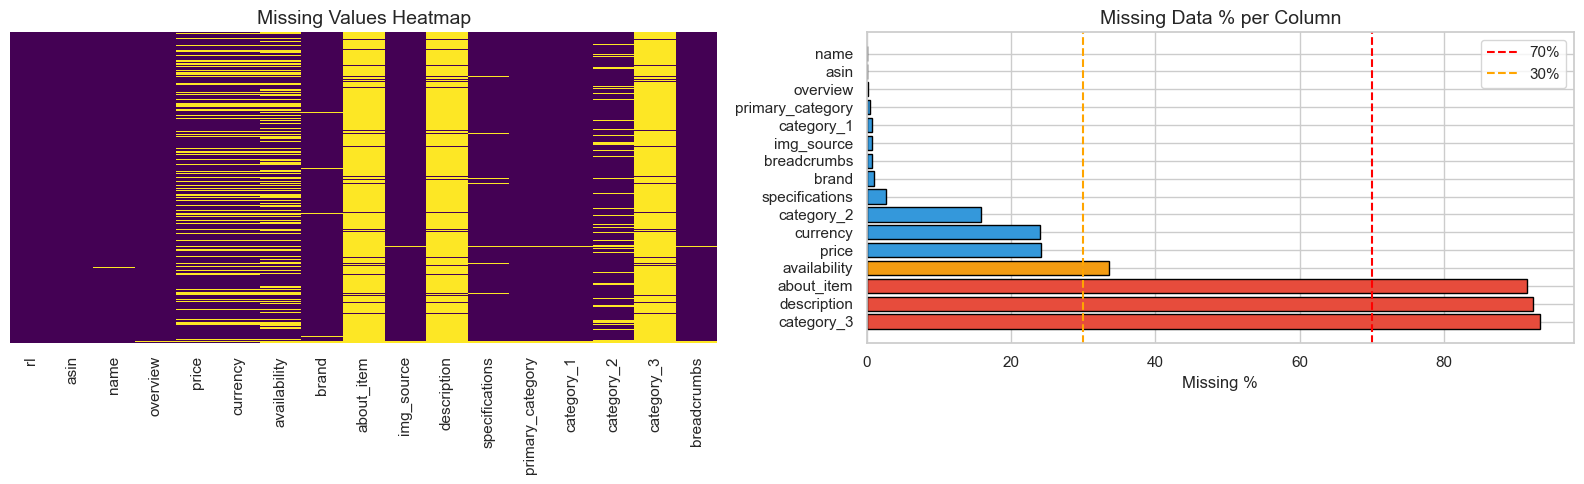

                  Missing Count  Missing Pct
category_3                 1349         93.3
description                1334         92.3
about_item                 1323         91.5
availability                486         33.6
price                       350         24.2
currency                    347         24.0
category_2                  229         15.8
specifications               39          2.7
brand                        14          1.0
breadcrumbs                  11          0.8
img_source                   11          0.8
category_1                   10          0.7
primary_category              7          0.5
overview                      3          0.2
asin                          2          0.1
name                          2          0.1


In [6]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df_raw.isnull().sum(),
    'Missing Pct': (df_raw.isnull().sum() / len(df_raw) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Aquí corregí 'Viridis' por 'viridis' con minúscula
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False,
            cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Values Heatmap')

mv = missing[missing['Missing Pct'] > 0]
colors_mv = ['#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
             for v in mv['Missing Pct']]

# Dibujar barras solo si hay columnas con valores faltantes
if not mv.empty:
    axes[1].barh(mv.index, mv['Missing Pct'], color=colors_mv, edgecolor='black')
    axes[1].axvline(70, color='red', linestyle='--', label='70%')
    axes[1].axvline(30, color='orange', linestyle='--', label='30%')
    axes[1].set_xlabel('Missing %')
    axes[1].set_title('Missing Data % per Column')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'No hay valores faltantes', 
                 horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4.Ingenieria de caracteristicas (Feature Engineering)

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>Ejemplo Cotidiano:</b> Un agente inmobiliario no solo utiliza los metros cuadrados brutos, sino que también considera la ubicación, la antiguedad y 
el estado. Nosotros hacemos lo mismo: extraemos información más valiosa del texto sin procesar y las categorías.
</div>

In [7]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

# print(f'✅ Total Caracteriscas (Atributos) Procesadas (Features Engineered): {len(df.columns)}')
print('\nPrecio por cada tipo (tier) de distribucion:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)


Precio por cada tipo (tier) de distribucion:
price_tier
1_budget     104
2_low        285
3_mid        319
4_premium    260
5_luxury     126
Unknown      352


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5.Análisis Univariante 📊

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>Las gráficas que generamos nos ayudan a visualizar el inventario de los productos de mi dataset y a mostrar qué grupos tienen el mayor volumen de datos. También nos muestran la disponibilidad de los artículos; en palabras simples,<b
nos dicen si hay stock o si se trata de un producto agotado.
    </div>

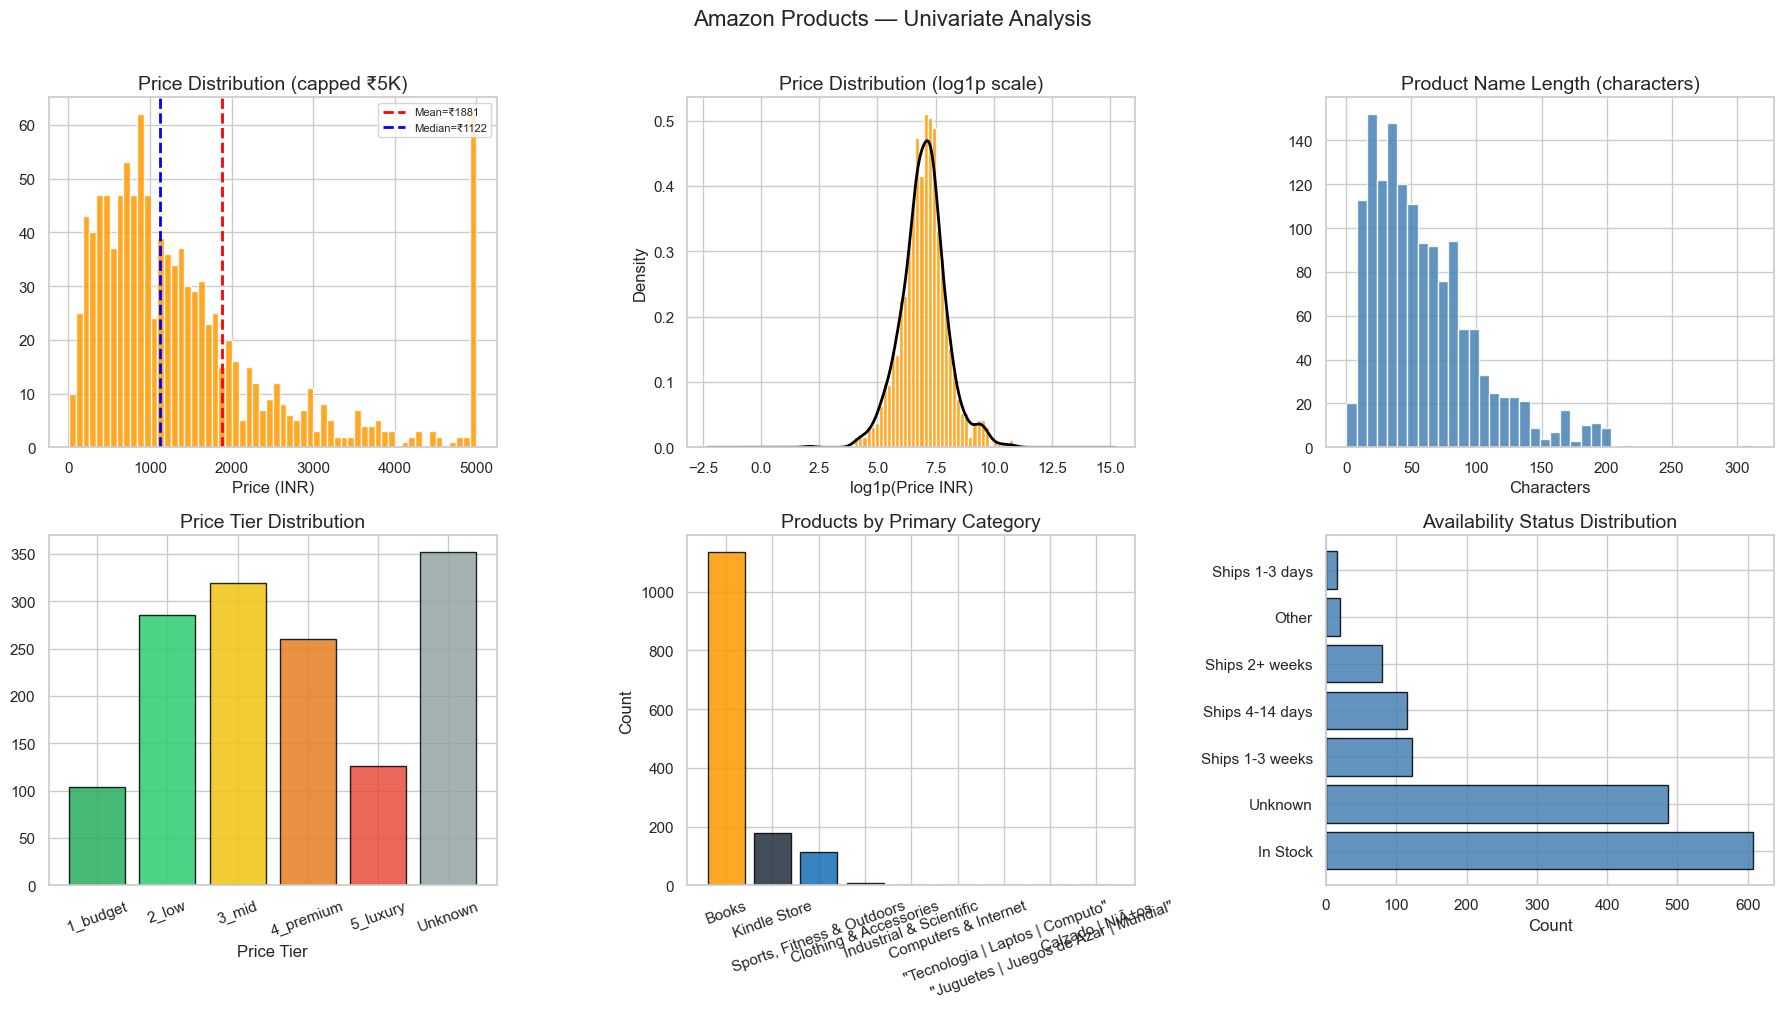

Shapiro-Wilk (log price, n=500): stat=0.9823, p=0.000009
Price is still non-normal after log transform

Price stats (INR):
count     1087.00
mean      1881.16
std       3339.62
min          7.00
25%        612.53
50%       1122.00
75%       1850.00
max      50555.00


In [8]:
# ============================================================
# SECTION 4 — Univariate Analysis
# ============================================================
from scipy.stats import shapiro
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Price raw
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_priced['price_clean'].mean(), color='red', linestyle='--',
                  lw=2, label=f'Mean=₹{df_priced["price_clean"].mean():.0f}')
axes[0,0].axvline(df_priced['price_clean'].median(), color='blue', linestyle='--',
                  lw=2, label=f'Median=₹{df_priced["price_clean"].median():.0f}')
axes[0,0].set_title('Price Distribution (capped ₹5K)')
axes[0,0].set_xlabel('Price (INR)'); axes[0,0].legend(fontsize=8)

# Price log
axes[0,1].hist(df_priced['log_price'], bins=50, color='#FF9900',
               edgecolor='white', alpha=0.85, density=True)
df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)
axes[0,1].set_title('Price Distribution (log1p scale)')
axes[0,1].set_xlabel('log1p(Price INR)')

# Name length
axes[0,2].hist(df['name_length'], bins=40, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,2].set_title('Product Name Length (characters)')
axes[0,2].set_xlabel('Characters')

# Price tier
tier_counts = df['price_tier'].value_counts().sort_index()
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']
axes[1,0].bar(tier_counts.index, tier_counts.values,
              color=tier_colors[:len(tier_counts)], edgecolor='black', alpha=0.85)
axes[1,0].set_title('Price Tier Distribution')
axes[1,0].set_xlabel('Price Tier'); axes[1,0].tick_params(axis='x', rotation=20)

# Primary category
cat_counts = df['primary_category'].value_counts()
axes[1,1].bar(cat_counts.index, cat_counts.values,
              color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
              edgecolor='black', alpha=0.85)
axes[1,1].set_title('Products by Primary Category')
axes[1,1].set_ylabel('Count'); axes[1,1].tick_params(axis='x', rotation=20)

# Availability
avail_counts = df['avail_clean'].value_counts()
axes[1,2].barh(avail_counts.index, avail_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Availability Status Distribution')
axes[1,2].set_xlabel('Count')

plt.suptitle('Amazon Products — Univariate Analysis', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

# Normality test
stat, p = shapiro(df_priced['log_price'].sample(min(500, len(df_priced)), random_state=42))
print(f'Shapiro-Wilk (log price, n=500): stat={stat:.4f}, p={p:.6f}')
print(f'Price is {"normally distributed after log transform" if p > 0.05 else "still non-normal after log transform"}')
print(f'\nPrice stats (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())

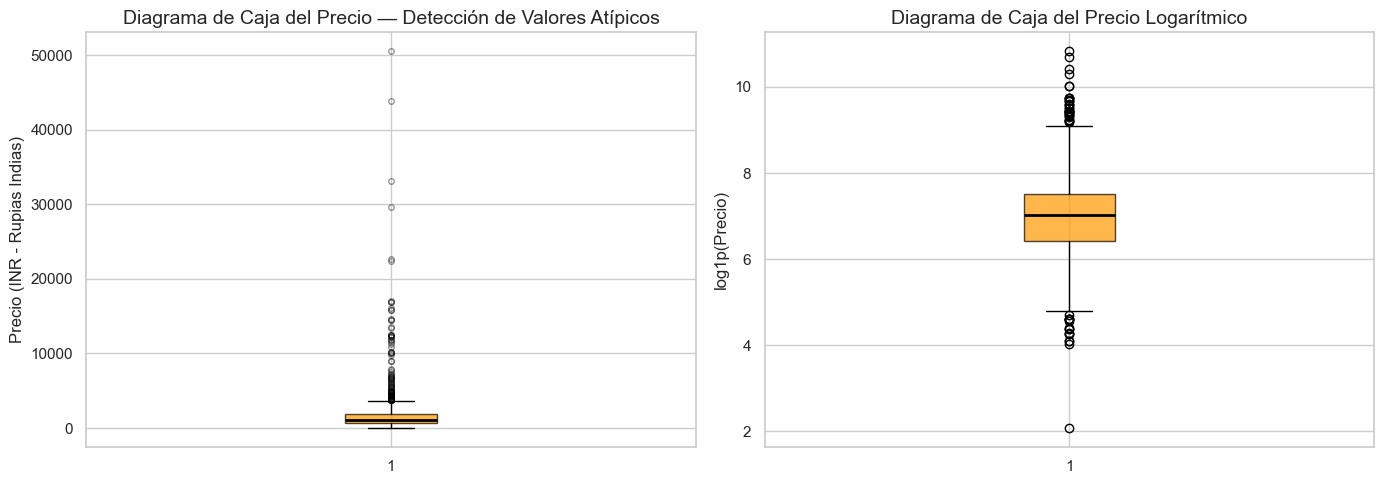

Valores atípicos por método IQR: 93 (8.6%)
Rango de precios (sin valores atípicos): ₹-1244 – ₹3706

Top 10 de productos más caros:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     

In [9]:
# ==============================================================================
# ANÁLISIS DE VALORES ATÍPICOS (OUTLIERS) — DIAGRAMA DE CAJA (BOXPLOT) e IQR
# ==============================================================================

# Creamos una figura con 1 fila y 2 columnas para mostrar dos gráficos lado a lado.
# El tamaño asignado de la figura completa es de 14 de ancho por 5 de alto.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Diagrama de Caja del Precio Original ---

# Dibuja un boxplot de los precios limpios en la primera posición [0].
# 'patch_artist=True' permite rellenar la caja con color.
# 'boxprops' define el color naranja de Amazon con un 70% de opacidad.
# 'medianprops' resalta la línea de la mediana en color negro y grosor de 2.
# 'flierprops' configura los puntos que representan los valores atípicos (en color rojo y semi-transparentes).
axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))

# Título y etiquetas en español para el primer gráfico
axes[0].set_title('Diagrama de Caja del Precio — Detección de Valores Atípicos')
axes[0].set_ylabel('Precio (INR - Rupias Indias)')


# --- Gráfico 2: Diagrama de Caja del Precio en Escala Logarítmica ---

# Dibuja un boxplot de la variable transformada 'log_price' en la segunda posición [1].
# Se usan los mismos estilos visuales para mantener consistencia.
axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))

# Título y etiquetas en español para el segundo gráfico
# Al aplicar logaritmo, se reduce la distancia visual que causan los productos caros.
axes[1].set_title('Diagrama de Caja del Precio Logarítmico')
axes[1].set_ylabel('log1p(Precio)')

# Ajusta el espacio para que los títulos y nombres de los ejes no se encimen.
plt.tight_layout()

# Muestra en pantalla el lienzo final con los dos diagramas de caja.
plt.show()


# --- Cálculo Matemático del Rango Intercuartílico (Método IQR) ---

# Calculamos el Primer Cuartil (Q1 - percentil 25) y el Tercer Cuartil (Q3 - percentil 75) del precio.
Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])

# El IQR es la distancia o rango que abarca el 50% de los datos centrales.
IQR = Q3 - Q1

# Identificamos como "outliers" o atípicos a los registros que estén:
# - Por debajo de: Q1 - (1.5 * IQR)
# - Por encima de: Q3 + (1.5 * IQR)
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]

# Imprime la cantidad total de productos atípicos encontrados y el porcentaje que representan en el dataset.
print(f'Valores atípicos por método IQR: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')

# Muestra el rango "normal" de precios calculado matemáticamente libre de valores extremos extremos.
print(f'Rango de precios (sin valores atípicos): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')


# --- Visualización de los Productos de Mayor Valor ---

# Imprime un encabezado para identificar los artículos más caros de la muestra.
print(f'\nTop 10 de productos más caros:')

# Ordena el dataset de mayor a menor según 'price_clean' y extrae las primeras 10 filas.
# Selecciona solo las columnas de 'name' (nombre), 'price_clean' (precio) y 'primary_category' (categoría).
# '.to_string(index=False)' oculta los números de índice de fila para que la tabla se imprima limpia.
print(df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].to_string(index=False))

## 6.Análisis de Categorías

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>Este análisis nos sirve para ver cuáles pasillos de la tienda acumulan más mercancía y cuáles manejan los precios más altos. Al revisar el volumen de artículos y cruzarlo con sus costos, podemos descubrir en qué partes del negocio se concentra el dinero real. Técnicamente, esto nos permite evaluar cómo se relacionan las variables de tipo texto (las categorías) con los valores numéricos (los precios), ayudándonos a identificar la concentración de los datos y el valor total acumulado antes de entrenar cualquier modelo de predicción. <b>
    </div>

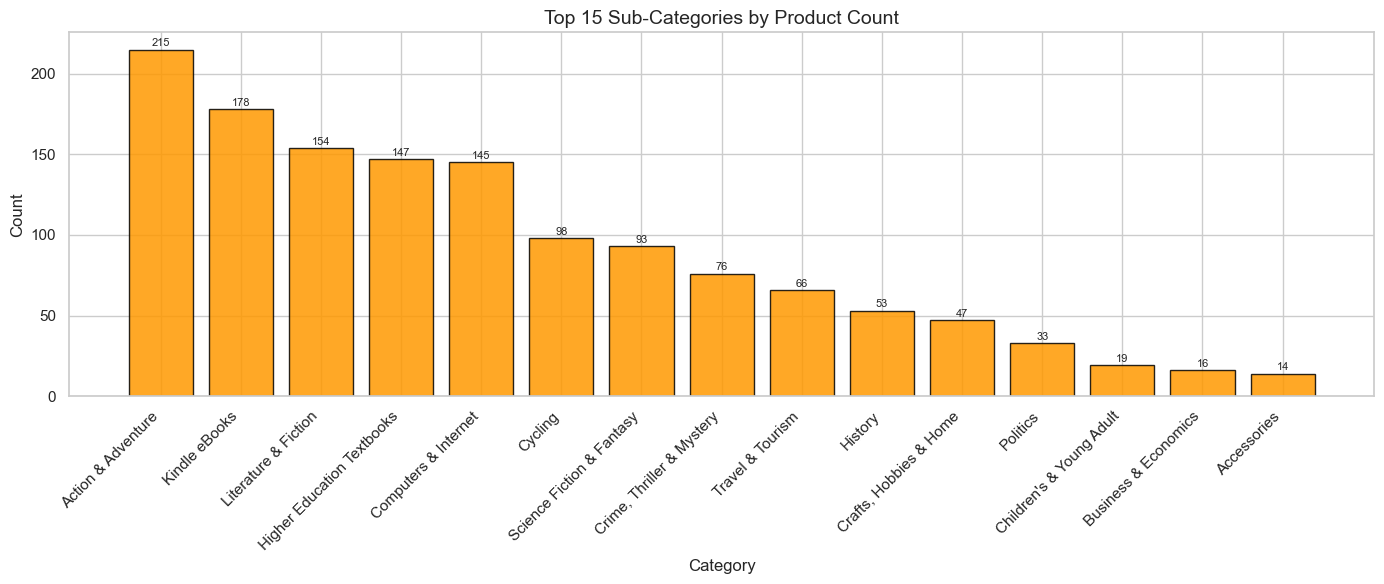

In [10]:
# ==============================================================================
# SECCIÓN 5 — ANÁLISIS DE CATEGORÍAS (CATEGORY ANALYSIS)
# ==============================================================================

# Cuenta cuántos productos pertenecen a cada subcategoría ('category_1').
# Con '.head(15)' seleccionamos únicamente las 15 subcategorías que tienen más productos en el dataset.
top15_cat1 = df['category_1'].value_counts().head(15)

# Crea el lienzo de la gráfica definiendo un tamaño de 14 de ancho por 6 de alto.
plt.figure(figsize=(14, 6))

# Dibuja un gráfico de barras verticales.
# Coloca los nombres de las 15 subcategorías en el eje X y sus cantidades en el eje Y.
# El color elegido es el naranja de Amazon ('#FF9900') con bordes negros y un 85% de opacidad.
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)

# --- Bucle para agregar etiquetas de datos (números sobre las barras) ---
# Recorre cada barra de la gráfica al mismo tiempo que su valor numérico correspondiente.
for bar, val in zip(bars, top15_cat1.values):
    # 'plt.text' coloca un texto en coordenadas específicas:
    # Eje X: El centro exacto de la barra actual (posición inicial X + la mitad de su ancho).
    # Eje Y: Justo arriba de la barra (la altura de la barra + 2 unidades de margen para que no choque).
    # 'str(val)' convierte el número a texto, 'ha='center'' lo alinea al centro y se define un tamaño de letra de 8.
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(val), ha='center', fontsize=8)

# Configura el título principal del gráfico y las etiquetas informativas de los ejes X e Y.
plt.title('Top 15 Sub-Categories by Product Count')
plt.xlabel('Category')
plt.ylabel('Count')

# Rota los nombres del eje X 45 grados y los alinea a la derecha ('ha='right'') para evitar que se encimen y sean legibles.
plt.xticks(rotation=45, ha='right')

# Ajusta automáticamente los márgenes de la imagen para que ninguna etiqueta ni texto quede recortado en los bordes.
plt.tight_layout()

# Despliega en pantalla el gráfico final con sus respectivas barras y números.
plt.show()

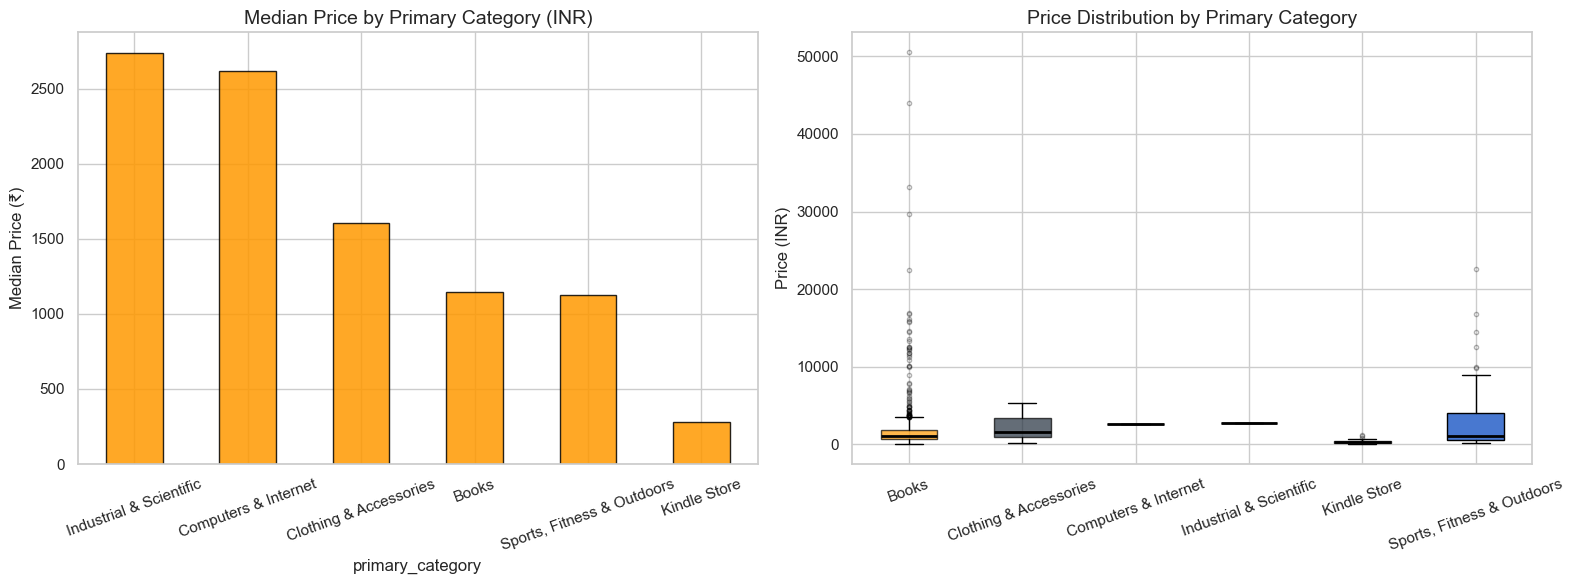

Price stats by primary category:
                              mean  median  count
primary_category                                 
Books                       1825.6  1145.0    955
Clothing & Accessories      2249.2  1606.5      6
Computers & Internet        2615.0  2615.0      1
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Sports, Fitness & Outdoors  2907.9  1125.0     93


In [11]:
# --- Configuración de los Gráficos ---
# Creamos una figura con 1 fila y 2 columnas para mostrar dos gráficos lado a lado.
# Definimos un tamaño de 16 de ancho por 6 de alto.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Cálculo de Estadísticas por Categoría ---
# Agrupamos los datos por la columna 'primary_category' (Categoría Principal).
# Usamos '.agg()' para calcular al mismo tiempo: el promedio ('mean'), la mediana ('median') y la cantidad de productos ('count').
# Redondeamos los resultados a 1 decimal (.round(1)).
cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)

# --- Gráfico 1: Barras de la Mediana de Precios ---
# Tomamos la columna de medianas, la ordenamos de mayor a menor y la graficamos en formato de barras (.plot.bar).
# 'ax=axes[0]' le indica a Python que este gráfico va en la primera posición (izquierda).
# Usamos el color naranja de Amazon, bordes negros y una opacidad del 85%.
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)

# Agregamos el título y la etiqueta del eje Y en el primer gráfico.
axes[0].set_title('Median Price by Primary Category (INR)')
axes[0].set_ylabel('Median Price (₹)')
# Rotamos los nombres de las categorías 20 grados para que se lean bien.
axes[0].tick_params(axis='x', rotation=20)


# --- Gráfico 2: Diagrama de Caja (Boxplot) por Categoría ---
# Creamos una lista llamada 'cat_groups'. Para cada categoría, filtramos sus precios limpios y eliminamos los valores nulos (.dropna()).
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]

# Dibujamos los diagramas de caja en la segunda posición (derecha: axes[1]).
# Pasamos la lista de grupos creada antes y le asignamos los nombres de las categorías como etiquetas.
# Configuramos la línea de la mediana en color negro y los valores atípicos (puntos) pequeños y transparentes.
bp = axes[1].boxplot(cat_groups, labels=cat_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))

# --- Personalización de Colores en el Boxplot ---
# Definimos una lista de colores representativos de Amazon.
colors_cat = ['#FF9900','#232F3E','#146EB4','#E47911','#999']

# Recorremos cada una de las "cajas" dibujadas y le asignamos un color de la lista con una opacidad del 70%.
for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color); patch.set_alpha(0.7)

# Agregamos el título y la etiqueta del eje Y en el segundo gráfico.
axes[1].set_title('Price Distribution by Primary Category')
axes[1].set_ylabel('Price (INR)')
# Rotamos los nombres de las categorías 20 grados.
axes[1].tick_params(axis='x', rotation=20)


# --- Ajustes de Impresión en Pantalla ---
# Ajustamos los espacios automáticamente para evitar que los textos de ambos gráficos se encimen.
plt.tight_layout()
# Desplegamos la figura en el cuaderno.
plt.show()

# --- Impresión de Tablas en Consola ---
# Imprimimos un texto de encabezado.
print('Price stats by primary category:')
# Convertimos la tabla de estadísticas calculada al inicio en texto y la mostramos completa.
print(cat_price.to_string())

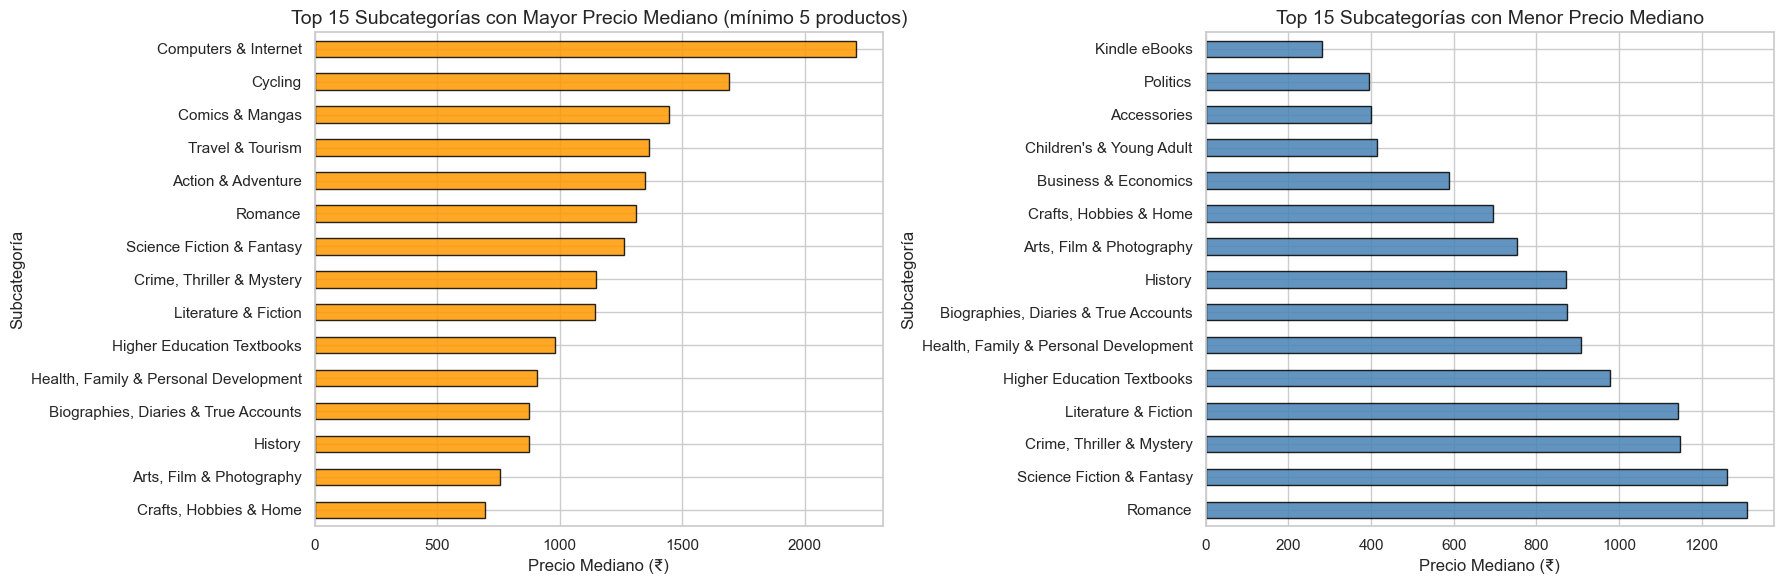

In [12]:
# --- Cálculo de las 15 Subcategorías Más Caras ---
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

# --- Configuración de los Gráficos ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Gráfico 1: Subcategorías Más Caras ---
top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Top 15 Subcategorías con Mayor Precio Mediano (mínimo 5 productos)')
axes[0].set_xlabel('Precio Mediano (₹)')
axes[0].set_ylabel('Subcategoría')

# --- Cálculo de las 15 Subcategorías Más Baratas ---
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))

# --- Gráfico 2: Subcategorías Más Baratas ---
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1],
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

axes[1].set_title('Top 15 Subcategorías con Menor Precio Mediano')
axes[1].set_xlabel('Precio Mediano (₹)')
axes[1].set_ylabel('Subcategoría')

# --- Ajustes Finales ---
plt.tight_layout()
plt.show()

## 7.Análisis de Disponibilidad

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color:#0066cc;">
<b>
Este análisis sirve para entender cómo se distribuye el inventario de los productos y
si el hecho de que un artículo esté agotado o disponible tiene alguna relación con su costo. Al cruzar los precios con el estado del stock,
podemos descubrir de forma sencilla si los productos más caros o exclusivos tienden a acabarse más rápido que los normales. Técnicamente, este 
bloque nos permite evaluar una variable categórica discreta mediante proporciones (porcentajes) y formas visuales, ayudándonos a comprobar si existe
patrones importantes en el comportamiento de la tienda antes de pasar a la etapa de predicción con los modelos.<b>
<div>

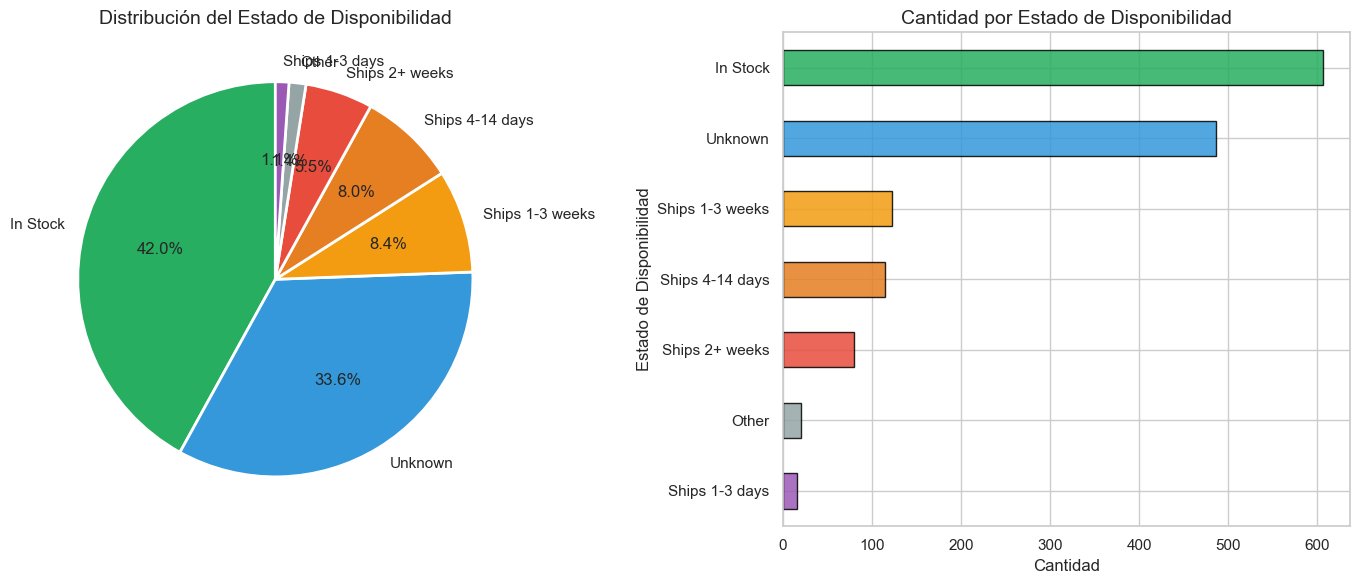

In [30]:
# ============================================================
# SECCIÓN 6 — Análisis de Disponibilidad
# ============================================================
avail_counts = df['avail_clean'].value_counts()

avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22',
                '#e74c3c','#95a5a6','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Gráfico Circular ---
axes[0].pie(
    avail_counts.values,
    labels=avail_counts.index,
    colors=avail_colors[:len(avail_counts)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

axes[0].set_title('Distribución del Estado de Disponibilidad')

# --- Gráfico de Barras Horizontales ---
avail_counts.sort_values().plot.barh(
    ax=axes[1],
    color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black',
    alpha=0.85
)

axes[1].set_title('Cantidad por Estado de Disponibilidad')
axes[1].set_xlabel('Cantidad')
axes[1].set_ylabel('Estado de Disponibilidad')

plt.tight_layout()
plt.show()

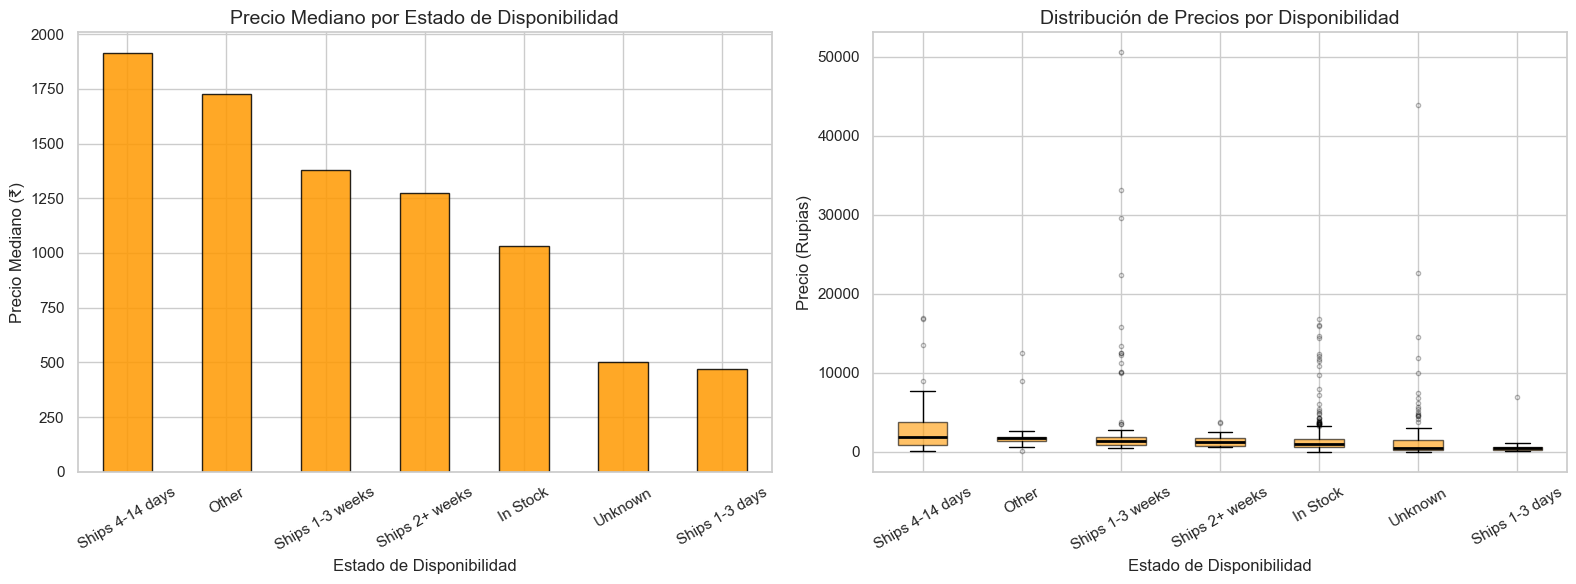

Precio según estado de disponibilidad:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1724.2  2459.4     20
Ships 1-3 weeks  1377.5  3226.6    122
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1030.0  1490.5    599
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [31]:
# Precio según estado de disponibilidad
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(
    ['median', 'mean', 'count']
).round(1)

avail_price = avail_price[avail_price['count'] >= 5].sort_values(
    'median', ascending=False
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico de barras ---
avail_price['median'].plot.bar(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Precio Mediano por Estado de Disponibilidad')
axes[0].set_ylabel('Precio Mediano (₹)')
axes[0].set_xlabel('Estado de Disponibilidad')
axes[0].tick_params(axis='x', rotation=30)

# --- Diagrama de caja ---
avail_groups = [
    df_priced[df_priced['avail_clean'] == a]['price_clean'].dropna()
    for a in avail_price.index
]

bp = axes[1].boxplot(
    avail_groups,
    labels=avail_price.index,
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)

for patch in bp['boxes']:
    patch.set_facecolor('#FF9900')
    patch.set_alpha(0.6)

axes[1].set_title('Distribución de Precios por Disponibilidad')
axes[1].set_ylabel('Precio (Rupias)')
axes[1].set_xlabel('Estado de Disponibilidad')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('Precio según estado de disponibilidad:')
print(avail_price.to_string())

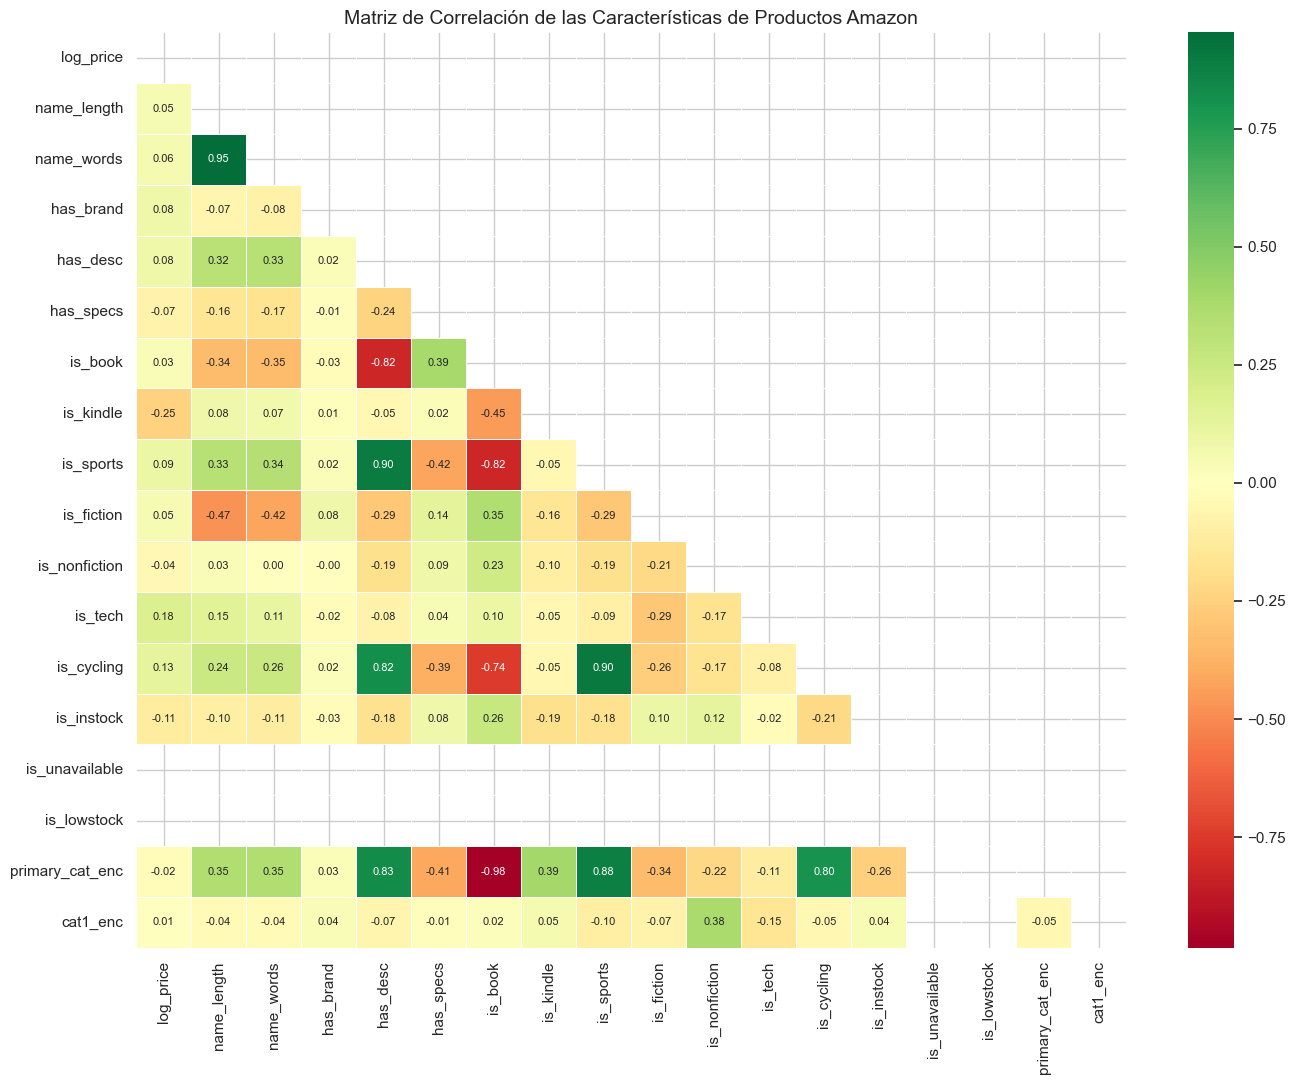

Correlaciones más altas con log_price:
is_tech            0.178700
is_cycling         0.126665
is_sports          0.091764
has_brand          0.083788
has_desc           0.083304
name_words         0.055104
is_fiction         0.052686
name_length        0.049775
is_book            0.034124
cat1_enc           0.006765
primary_cat_enc   -0.019787
is_nonfiction     -0.044517
has_specs         -0.074902
is_instock        -0.114018
is_kindle         -0.246647
is_unavailable          NaN
is_lowstock             NaN


In [34]:
# ============================================================
# SECCIÓN 7 — Análisis de Correlación
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.4,
    annot_kws={'size': 8}
)

plt.title('Matriz de Correlación de las Características de Productos Amazon',
          fontsize=14)

plt.tight_layout()
plt.show()

print('Correlaciones más altas con log_price:')
print(
    corr['log_price']
    .drop('log_price')
    .sort_values(ascending=False)
    .to_string()
)

## 8.ANÁLISIS DE CORRELACIÓN

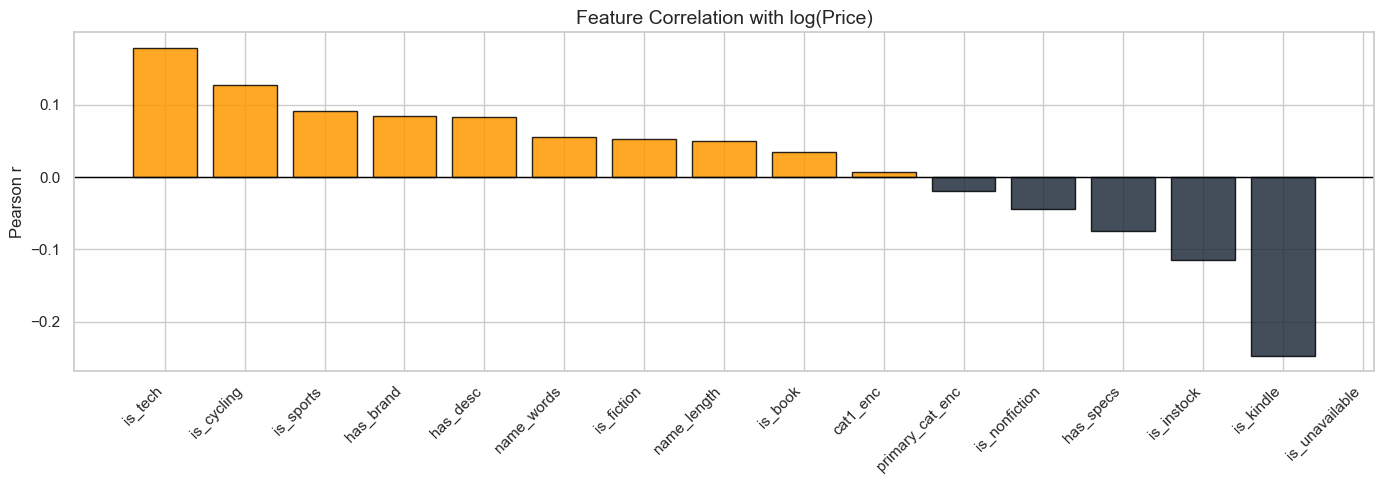

In [17]:
# Feature correlation bar chart
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Feature Correlation with log(Price)')
plt.ylabel('Pearson r'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

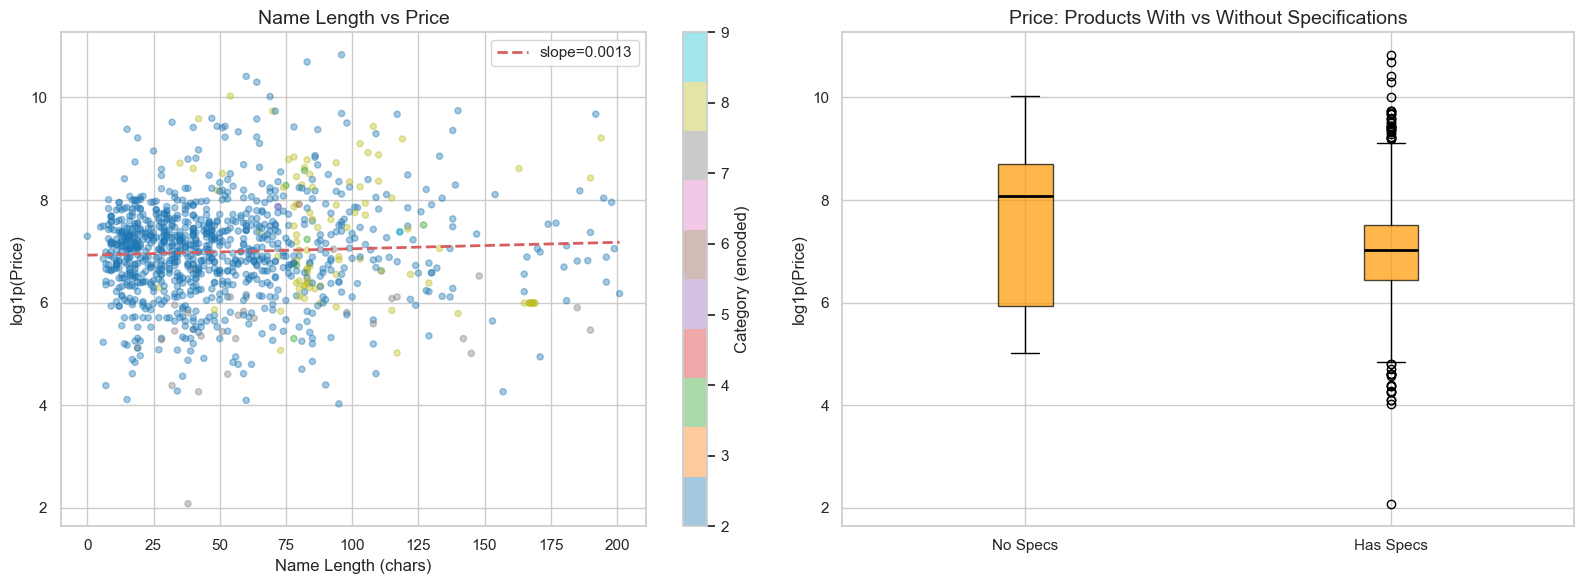

In [18]:
# Scatter: name length vs price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df_priced['name_length'], df_priced['log_price'],
                     c=df_priced['primary_cat_enc'], cmap='tab10',
                     alpha=0.4, s=20)
plt.colorbar(sc, ax=axes[0], label='Category (encoded)')
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'slope={m:.4f}')
axes[0].set_xlabel('Name Length (chars)'); axes[0].set_ylabel('log1p(Price)')
axes[0].set_title('Name Length vs Price'); axes[0].legend()

# Price by has_specs
axes[1].boxplot([np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
                 np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
                labels=['No Specs','Has Specs'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Price: Products With vs Without Specifications')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()

## 9. Prueba Estadística de Hipótesis 

> **Justificación:**  
> Se emplean pruebas no paramétricas (**Kruskal-Wallis** y **Mann-Whitney U**) porque la variable **precio** presenta una distribución altamente sesgada y no normal.
>
> **Nivel de significancia:** α = 0.05

| # | Hipótesis | Prueba Estadística |
|---|-----------|-------------------|
| H1 | El precio difiere significativamente entre las categorías principales. | Kruskal-Wallis |
| H2 | Los libros tienen un precio significativamente menor que los productos deportivos. | Mann-Whitney U |
| H3 | El precio de los productos en existencia difiere significativamente del de los productos no disponibles. | Mann-Whitney U |
| H4 | La longitud del nombre del producto se correlaciona positivamente con el precio. | Correlación de Spearman |
| H5 | Los productos que incluyen especificaciones tienen precios más altos. | Mann-Whitney U |

In [19]:
# ============================================================
# SECTION 8 — Hypothesis Testing
# ============================================================
alpha = 0.05

def mw_test(name, a, b, la, lb):
    u, p = mannwhitneyu(a.dropna(), b.dropna(), alternative='two-sided')
    print(f'{name}')
    print(f'  {la}: n={len(a.dropna())}, median=₹{a.median():.0f}')
    print(f'  {lb}: n={len(b.dropna())}, median=₹{b.median():.0f}')
    print(f'  Mann-Whitney U={u:.0f}, p={p:.6f}')
    print(f'  RESULT: {"✅ REJECT H0 — Significant difference." if p < alpha else "❌ FAIL TO REJECT H0."}')
    print()
    return p

# H1: Price across primary categories — Kruskal-Wallis
cat_groups_kw = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
                 for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]
cat_labels_kw = [c for c in df_priced['primary_category'].unique()
                 if len(df_priced[df_priced['primary_category']==c]) >= 5]
h1, p1 = kruskal(*cat_groups_kw)
print(f'H1: Price across Primary Categories — Kruskal-Wallis')
for label, g in zip(cat_labels_kw, cat_groups_kw):
    print(f'  {label:35s}: n={len(g)}, median=₹{g.median():.0f}')
print(f'  H={h1:.4f}, p={p1:.6f}')
print(f'  RESULT: {"✅ REJECT H0 — Price differs across categories." if p1 < alpha else "❌ FAIL TO REJECT H0."}')
print()

# H2: Books vs Sports
p2 = mw_test('H2: Books vs Sports Products Price',
             df_priced[df_priced['is_book']==1]['price_clean'],
             df_priced[df_priced['is_sports']==1]['price_clean'],
             'Books', 'Sports')

# H3: In Stock vs Unavailable
p3 = mw_test('H3: In-Stock vs Unavailable Price',
             df_priced[df_priced['is_instock']==1]['price_clean'],
             df_priced[df_priced['is_unavailable']==1]['price_clean'],
             'In Stock', 'Unavailable')

# H4: Name length vs price — Spearman
rho4, p4 = spearmanr(df_priced['name_length'], df_priced['price_clean'])
print(f'H4: Name Length vs Price — Spearman Correlation')
print(f'  rho={rho4:.4f}, p={p4:.6f}')
print(f'  RESULT: {"✅ REJECT H0 — Significant correlation." if p4 < alpha else "❌ FAIL TO REJECT H0."}')
print()

# H5: Has specs vs no specs
p5 = mw_test('H5: Products With vs Without Specifications',
             df_priced[df_priced['has_specs']==1]['price_clean'],
             df_priced[df_priced['has_specs']==0]['price_clean'],
             'Has Specs', 'No Specs')

H1: Price across Primary Categories — Kruskal-Wallis
  Books                              : n=955, median=₹1145
  Sports, Fitness & Outdoors         : n=93, median=₹1125
  Kindle Store                       : n=30, median=₹281
  Clothing & Accessories             : n=6, median=₹1606
  H=55.8663, p=0.000000
  RESULT: ✅ REJECT H0 — Price differs across categories.

H2: Books vs Sports Products Price
  Books: n=955, median=₹1145
  Sports: n=93, median=₹1125
  Mann-Whitney U=40247, p=0.135443
  RESULT: ❌ FAIL TO REJECT H0.

H3: In-Stock vs Unavailable Price
  In Stock: n=599, median=₹1030
  Unavailable: n=0, median=₹nan
  Mann-Whitney U=nan, p=nan
  RESULT: ❌ FAIL TO REJECT H0.

H4: Name Length vs Price — Spearman Correlation
  rho=0.0351, p=0.247712
  RESULT: ❌ FAIL TO REJECT H0.

H5: Products With vs Without Specifications
  Has Specs: n=1065, median=₹1117
  No Specs: n=22, median=₹3278
  Mann-Whitney U=9290, p=0.096151
  RESULT: ❌ FAIL TO REJECT H0.



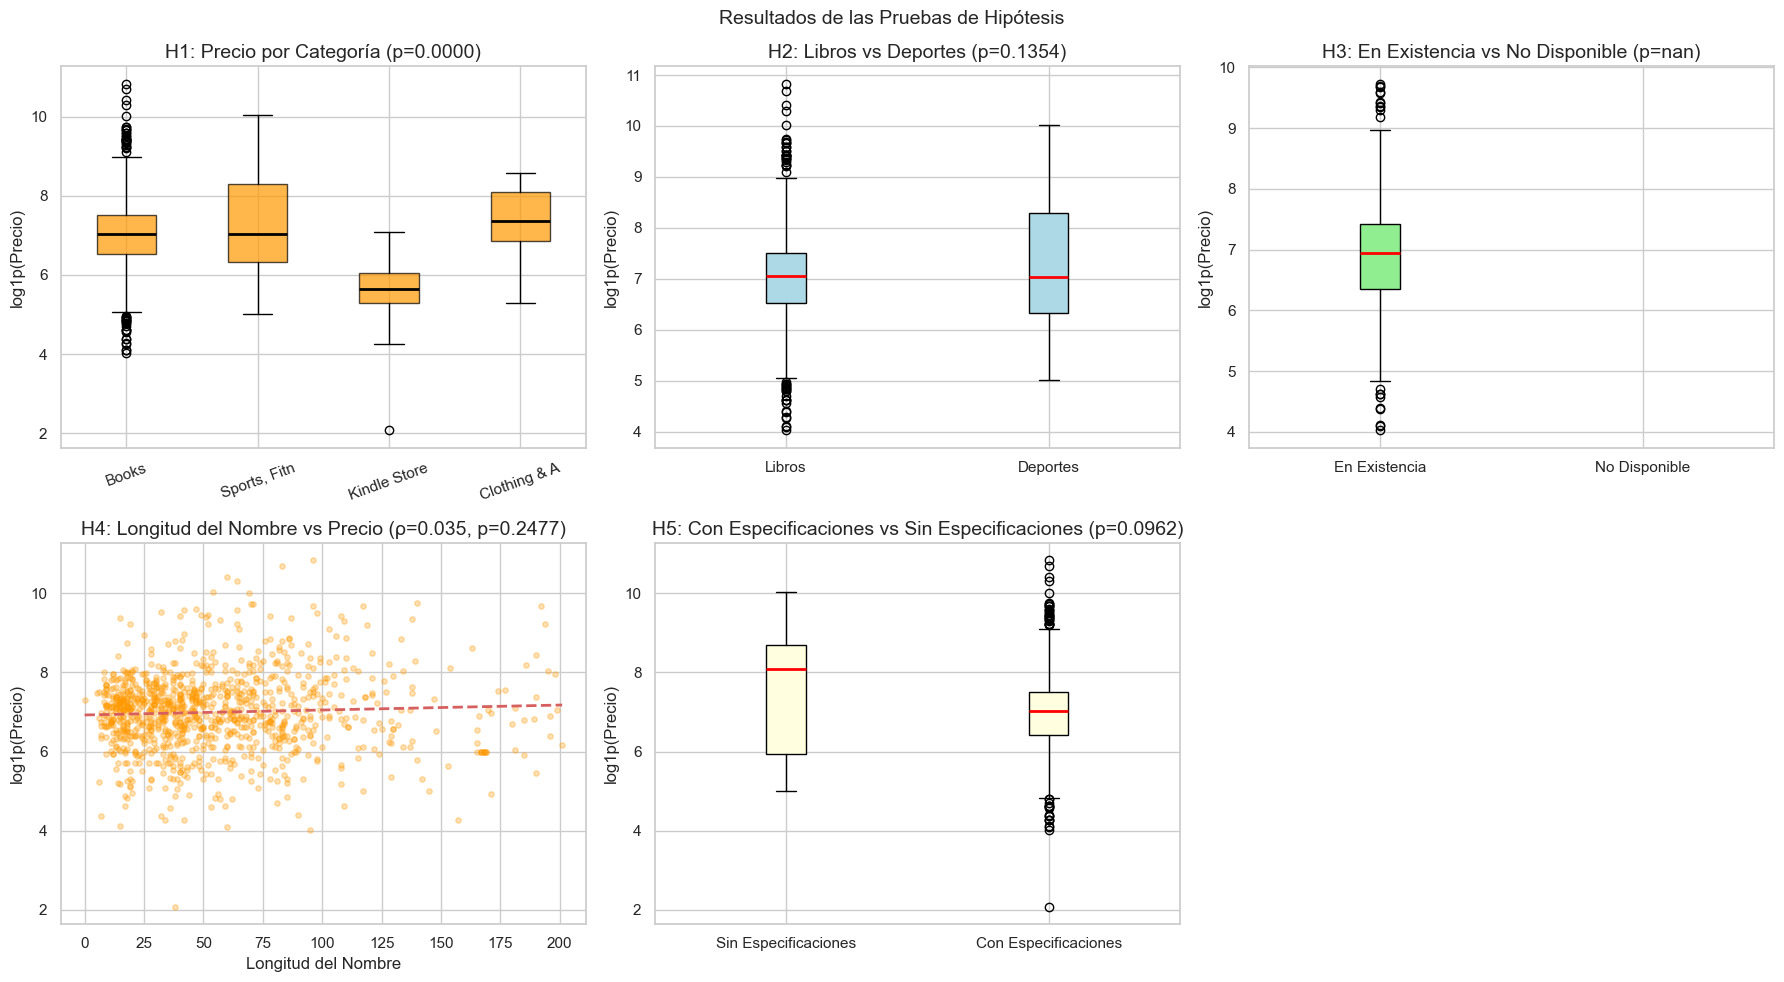

In [35]:
# Visualización de los resultados de las hipótesis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# H1
axes[0,0].boxplot(
    [np.log1p(g) for g in cat_groups_kw],
    labels=[l[:12] for l in cat_labels_kw],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)

axes[0,0].set_title(f'H1: Precio por Categoría (p={p1:.4f})')
axes[0,0].set_ylabel('log1p(Precio)')
axes[0,0].tick_params(axis='x', rotation=20)

# H2
axes[0,1].boxplot(
    [
        np.log1p(df_priced[df_priced['is_book']==1]['price_clean']),
        np.log1p(df_priced[df_priced['is_sports']==1]['price_clean'])
    ],
    labels=['Libros', 'Deportes'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', lw=2)
)

axes[0,1].set_title(f'H2: Libros vs Deportes (p={p2:.4f})')
axes[0,1].set_ylabel('log1p(Precio)')

# H3
axes[0,2].boxplot(
    [
        np.log1p(df_priced[df_priced['is_instock']==1]['price_clean']),
        np.log1p(df_priced[df_priced['is_unavailable']==1]['price_clean'])
    ],
    labels=['En Existencia', 'No Disponible'],
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen'),
    medianprops=dict(color='red', lw=2)
)

axes[0,2].set_title(f'H3: En Existencia vs No Disponible (p={p3:.4f})')
axes[0,2].set_ylabel('log1p(Precio)')

# H4
axes[1,0].scatter(
    df_priced['name_length'],
    df_priced['log_price'],
    alpha=0.3,
    color='#FF9900',
    s=15
)

m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)

axes[1,0].plot(x, m*x+b, 'r--', lw=2)

axes[1,0].set_title(
    f'H4: Longitud del Nombre vs Precio (ρ={rho4:.3f}, p={p4:.4f})'
)

axes[1,0].set_xlabel('Longitud del Nombre')
axes[1,0].set_ylabel('log1p(Precio)')

# H5
axes[1,1].boxplot(
    [
        np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
        np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])
    ],
    labels=['Sin Especificaciones', 'Con Especificaciones'],
    patch_artist=True,
    boxprops=dict(facecolor='lightyellow'),
    medianprops=dict(color='red', lw=2)
)

axes[1,1].set_title(
    f'H5: Con Especificaciones vs Sin Especificaciones (p={p5:.4f})'
)

axes[1,1].set_ylabel('log1p(Precio)')

# Ocultar el último espacio vacío
axes[1,2].set_visible(False)

plt.suptitle('Resultados de las Pruebas de Hipótesis', fontsize=14)

plt.tight_layout()
plt.show()

## 10. Planteamiento del Problema de Machine Learning 🎯

> **Tarea:** Predecir el precio del producto (escala logarítmica) a partir de la categoría, la longitud del nombre, la disponibilidad y las características del producto.
>
> **¿Por qué utilizar el logaritmo del precio?**  
> Los precios originales presentan una distribución fuertemente sesgada hacia la derecha. La transformación logarítmica permite obtener una distribución más cercana a la normalidad y evita que los valores atípicos de precios muy altos dominen la función de pérdida del modelo.

✅ Tamaño del conjunto de datos ML: (1087, 20)
✅ Número de características      : 18

Entrenamiento: 869 | Prueba: 218


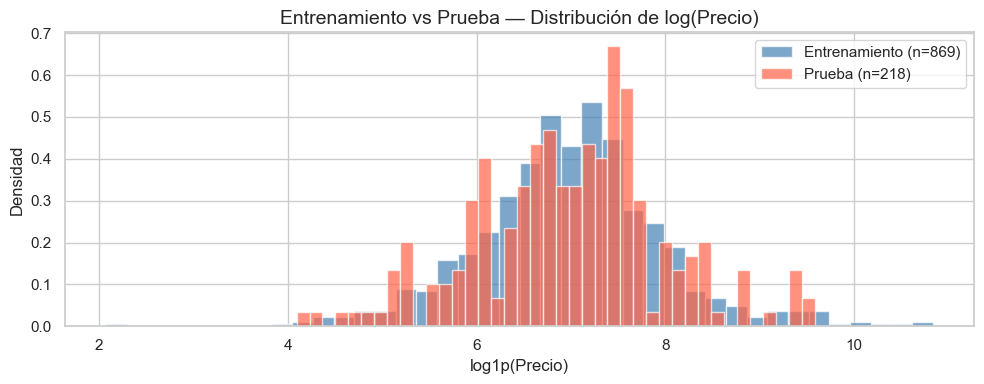

✅ Las distribuciones son similares: ¡buena división de los datos!


In [36]:
# ============================================================
# SECCIÓN 9 — Planteamiento del Problema de Machine Learning
# ============================================================
FEATURE_COLS = [
    'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
    'is_book', 'is_kindle', 'is_sports',
    'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
    'is_instock', 'is_unavailable', 'is_lowstock',
    'primary_cat_enc', 'cat1_enc', 'avail_enc',
]

TARGET = 'log_price'

df_ml = df_priced[FEATURE_COLS + [TARGET, 'price_clean']].dropna().copy()

print(f'✅ Tamaño del conjunto de datos ML: {df_ml.shape}')
print(f'✅ Número de características      : {len(FEATURE_COLS)}')

X = df_ml[FEATURE_COLS]
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nEntrenamiento: {len(X_train):,} | Prueba: {len(X_test):,}')

# Visualización de la división de datos
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    y_train,
    bins=40,
    color='steelblue',
    alpha=0.7,
    label=f'Entrenamiento (n={len(y_train)})',
    density=True
)

ax.hist(
    y_test,
    bins=40,
    color='tomato',
    alpha=0.7,
    label=f'Prueba (n={len(y_test)})',
    density=True
)

ax.set_title('Entrenamiento vs Prueba — Distribución de log(Precio)')
ax.set_xlabel('log1p(Precio)')
ax.set_ylabel('Densidad')
ax.legend()

plt.tight_layout()
plt.show()

print('✅ Las distribuciones son similares: ¡buena división de los datos!')

## 11. Comparación de Modelos

| Modelo | Fortalezas | Debilidades | Mejor Uso |
|----------|------------|-------------|------------|
| Regresión Lineal | Rápida e interpretable | Asume una relación lineal | Modelo base |
| Regresión Ridge | Maneja la multicolinealidad | Sigue siendo lineal | Variables correlacionadas |
| Regresión Lasso | Selección automática de variables | Puede eliminar variables útiles | Datos con muchas variables |
| Bosque Aleatorio (Random Forest) | No lineal y robusto | Menos interpretable | Patrones complejos |
| XGBoost / GBM | Mayor precisión | Requiere ajuste de hiperparámetros | Datos tabulares |

---

## Métricas de Evaluación

- **MAE** — Error Absoluto Medio en escala logarítmica *(menor = mejor)*

- **RMSE** — Raíz del Error Cuadrático Medio *(penaliza más los errores grandes)*

- **R²** — Coeficiente de Determinación o Varianza Explicada *(mayor = mejor, máximo 1.0)*

- **MAE (₹)** — Error Absoluto Medio transformado nuevamente a Rupias para facilitar la interpretación del negocio

In [38]:
# ============================================================
# SECTION 10 — Evaluation Helpers
# ============================================================
results = {}

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mae_inr = mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))
    print(f'  📊 {name}:')
    print(f'     MAE (log)  = {mae:.4f}  |  MAE (₹) = ₹{mae_inr:,.0f}')
    print(f'     RMSE (log) = {rmse:.4f}  |  R²      = {r2:.4f}')
    results[name] = {'MAE_log': round(mae,4), 'RMSE_log': round(rmse,4),
                     'R2': round(r2,4), 'MAE_INR': round(mae_inr,0)}
    return y_pred

print('✅ Ayudantes de evaluación listos.')



✅ Ayudantes de evaluación listos.


In [40]:
# ============================================================
# SECCIÓN 11 — Entrenamiento de Todos los Modelos
# ============================================================
print('=' * 60)
print('ENTRENAMIENTO DE TODOS LOS MODELOS')
print('=' * 60)

# 1. Regresión Lineal
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_pred = eval_model('Regresión Lineal', y_test, lr.predict(X_test_s))

# 2. Regresión Ridge
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train)
ridge_pred = eval_model('Regresión Ridge', y_test, ridge.predict(X_test_s))

# 3. Regresión Lasso
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_s, y_train)
lasso_pred = eval_model('Regresión Lasso', y_test, lasso.predict(X_test_s))

# 4. Bosque Aleatorio
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = eval_model('Bosque Aleatorio', y_test, rf.predict(X_test))

# 5. XGBoost / Gradient Boosting
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0
    )

    xgb_model.fit(X_train, y_train)
    xgb_pred = eval_model(
        'XGBoost',
        y_test,
        xgb_model.predict(X_test)
    )

else:
    gbm = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=42
    )

    gbm.fit(X_train, y_train)
    xgb_pred = eval_model(
        'Gradient Boosting',
        y_test,
        gbm.predict(X_test)
    )

ENTRENAMIENTO DE TODOS LOS MODELOS
  📊 Regresión Lineal:
     MAE (log)  = 0.7548  |  MAE (₹) = ₹1,188
     RMSE (log) = 0.9698  |  R²      = 0.0622
  📊 Regresión Ridge:
     MAE (log)  = 0.7533  |  MAE (₹) = ₹1,186
     RMSE (log) = 0.9643  |  R²      = 0.0728
  📊 Regresión Lasso:
     MAE (log)  = 0.7549  |  MAE (₹) = ₹1,187
     RMSE (log) = 0.9648  |  R²      = 0.0719
  📊 Bosque Aleatorio:
     MAE (log)  = 0.6984  |  MAE (₹) = ₹1,110
     RMSE (log) = 0.8888  |  R²      = 0.2123
  📊 Gradient Boosting:
     MAE (log)  = 0.7403  |  MAE (₹) = ₹1,153
     RMSE (log) = 0.9462  |  R²      = 0.1073


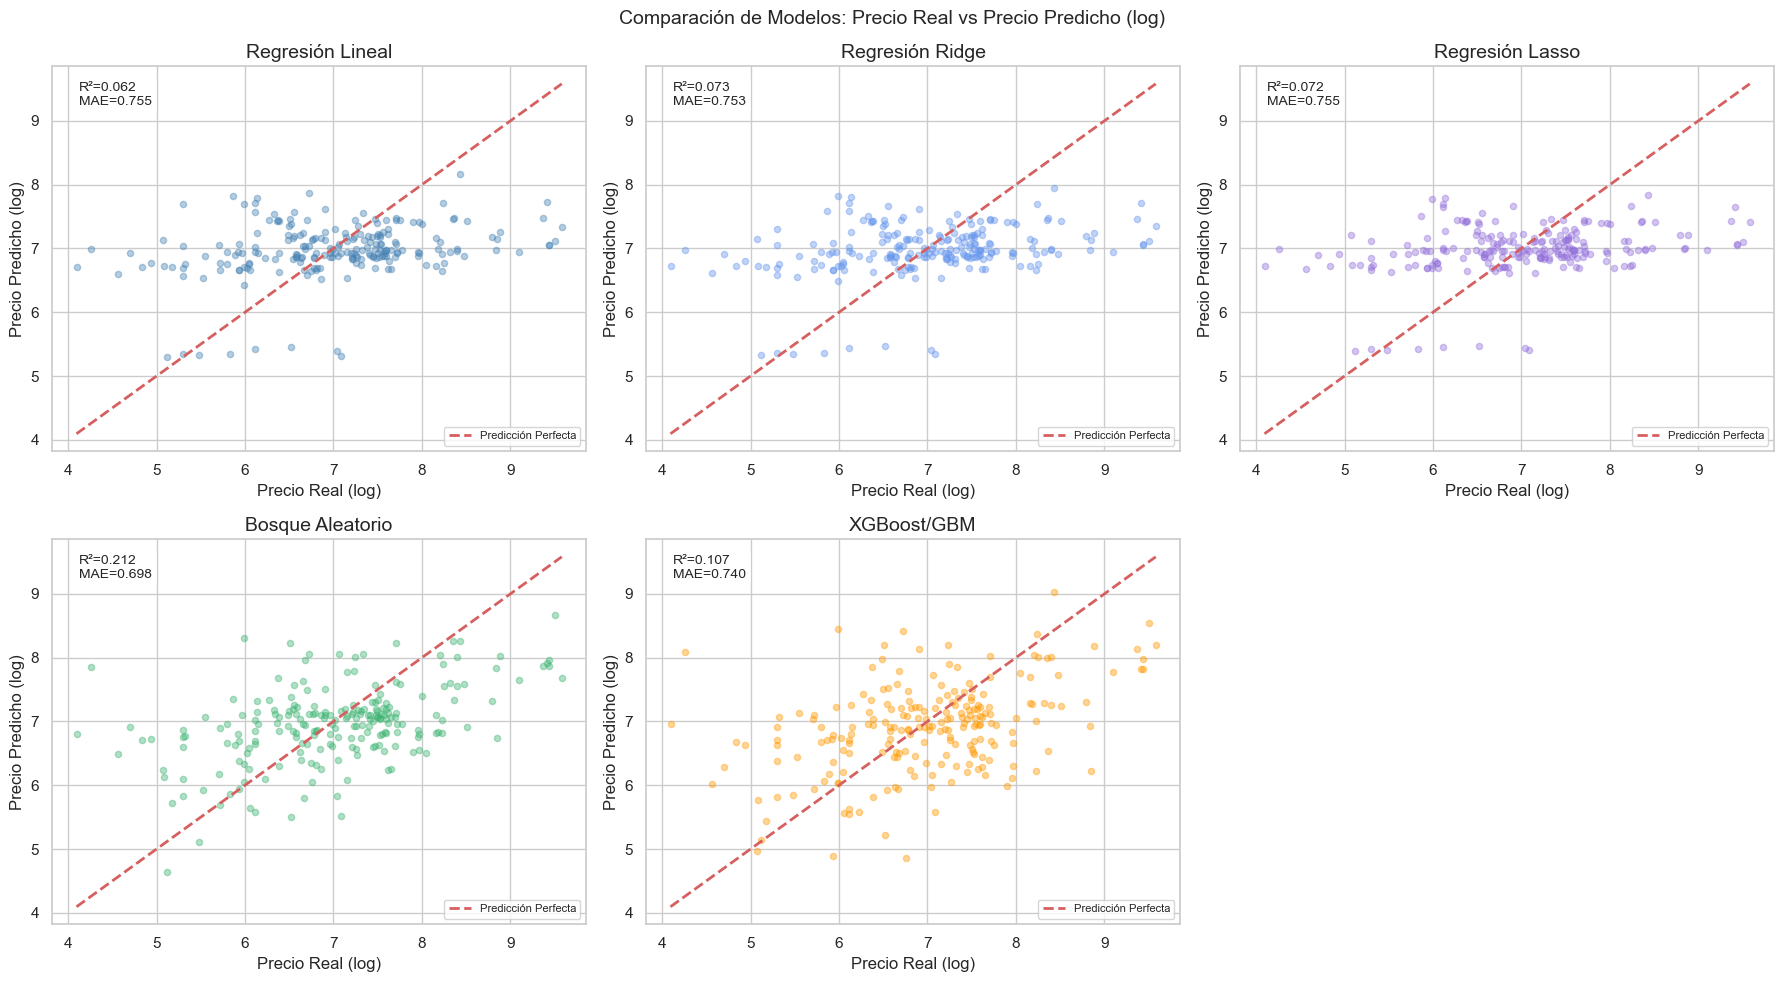

In [41]:
# Predicciones Reales vs Predicciones — Todos los Modelos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

preds_all = [
    ('Regresión Lineal', lr_pred, 'steelblue'),
    ('Regresión Ridge', ridge_pred, 'cornflowerblue'),
    ('Regresión Lasso', lasso_pred, 'mediumpurple'),
    ('Bosque Aleatorio', rf_pred, 'mediumseagreen'),
    ('XGBoost/GBM', xgb_pred, '#FF9900')
]

for ax, (name, pred, color) in zip(axes.flatten(), preds_all):

    ax.scatter(y_test, pred, alpha=0.4, color=color, s=20)

    lims = [
        min(y_test.min(), pred.min()),
        max(y_test.max(), pred.max())
    ]

    ax.plot(
        lims,
        lims,
        'r--',
        lw=2,
        label='Predicción Perfecta'
    )

    r2v = r2_score(y_test, pred)
    maev = mean_absolute_error(y_test, pred)

    ax.set_title(name)

    ax.set_xlabel('Precio Real (log)')
    ax.set_ylabel('Precio Predicho (log)')

    ax.annotate(
        f'R²={r2v:.3f}\nMAE={maev:.3f}',
        xy=(0.05, 0.90),
        xycoords='axes fraction',
        fontsize=10,
        bbox=dict(
            boxstyle='round',
            fc='white',
            alpha=0.85
        )
    )

    ax.legend(fontsize=8)

# Ocultar el último subplot vacío
axes.flatten()[-1].set_visible(False)

plt.suptitle(
    'Comparación de Modelos: Precio Real vs Precio Predicho (log)',
    fontsize=14
)

plt.tight_layout()
plt.show()

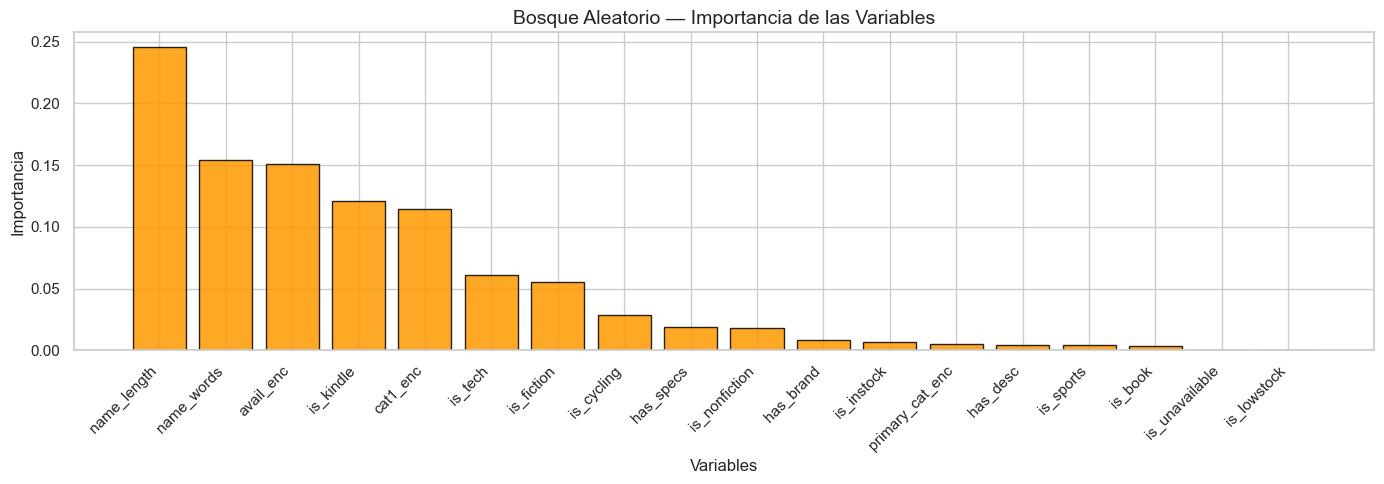

Las 10 variables más importantes:
     Variable  Importancia
  name_length     0.245198
   name_words     0.154159
    avail_enc     0.150559
    is_kindle     0.121088
     cat1_enc     0.114166
      is_tech     0.061342
   is_fiction     0.055122
   is_cycling     0.028367
    has_specs     0.019164
is_nonfiction     0.017840


In [42]:
# Importancia de Variables — Bosque Aleatorio
feat_imp = pd.DataFrame({
    'Variable': FEATURE_COLS,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(14, 5))

plt.bar(
    feat_imp['Variable'],
    feat_imp['Importancia'],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

plt.title('Bosque Aleatorio — Importancia de las Variables')
plt.ylabel('Importancia')
plt.xlabel('Variables')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print('Las 10 variables más importantes:')
print(feat_imp.head(10).to_string(index=False))

## 12. Ajuste de Hiperparámetros 🔧

<div style="
    background-color:#e8f5e9;
    border-left:5px solid #34a853;
    padding:15px;
    border-radius:6px;
    margin:10px 0;
    color:#0d47a1;
    font-size:16px;
    line-height:1.8;
">
    <strong>Ejemplo cotidiano:</strong>
    Un chef ajusta los condimentos hasta que el platillo queda perfecto.
    De manera similar, <strong>GridSearchCV</strong> prueba sistemáticamente
    diferentes combinaciones de hiperparámetros para encontrar la configuración
    que produce el mejor rendimiento del modelo.
</div>

In [46]:
# ============================================================
# SECCIÓN 12 — GridSearchCV para Bosque Aleatorio
# ============================================================
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 10, None],
    'min_samples_leaf': [1, 3, 5],
}

print('🔍 Ejecutando GridSearchCV (esto puede tardar entre 1 y 2 minutos)...')

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print(f'✅ Mejores hiperparámetros : {grid_search.best_params_}')
print(f'✅ Mejor MAE en validación cruzada : {-grid_search.best_score_:.4f}')

# Evaluar el modelo optimizado
best_rf = grid_search.best_estimator_

best_pred = best_rf.predict(X_test)

tuned_result = eval_model(
    'Bosque Aleatorio (Optimizado)',
    y_test,
    best_pred
)

results['Bosque Aleatorio (Optimizado)'] = tuned_result

🔍 Ejecutando GridSearchCV (esto puede tardar entre 1 y 2 minutos)...
✅ Mejores hiperparámetros : {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}
✅ Mejor MAE en validación cruzada : 0.6400
  📊 Bosque Aleatorio (Optimizado):
     MAE (log)  = 0.6915  |  MAE (₹) = ₹1,103
     RMSE (log) = 0.8806  |  R²      = 0.2268


Bosque Aleatorio (Optimizado) — Validación Cruzada de 5 Pliegues:
  Pliegue 1: MAE = 0.6409
  Pliegue 2: MAE = 0.6464
  Pliegue 3: MAE = 0.6803
  Pliegue 4: MAE = 0.6235
  Pliegue 5: MAE = 0.6139
  MAE Promedio : 0.6410 ± 0.0228


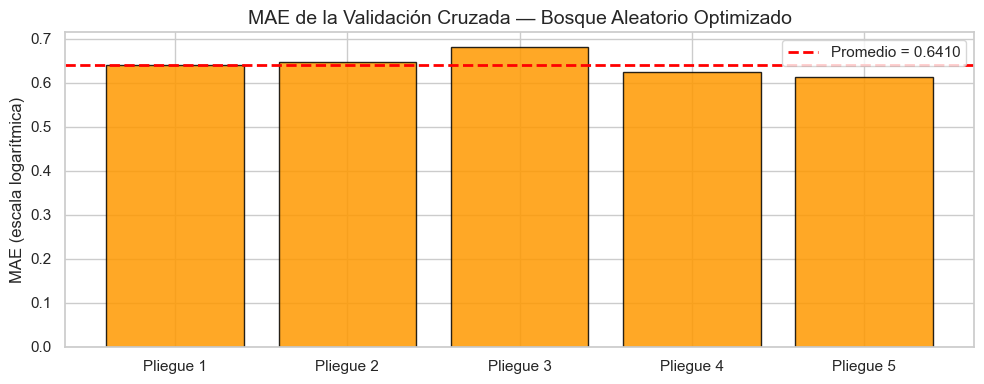

In [47]:
# Validación cruzada — modelo optimizado
cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

cv_mae = -cv_scores

print('Bosque Aleatorio (Optimizado) — Validación Cruzada de 5 Pliegues:')

for i, score in enumerate(cv_mae):
    print(f'  Pliegue {i+1}: MAE = {score:.4f}')

print(
    f'  MAE Promedio : {cv_mae.mean():.4f} ± {cv_mae.std():.4f}'
)

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    range(1, 6),
    cv_mae,
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

ax.axhline(
    cv_mae.mean(),
    color='red',
    linestyle='--',
    lw=2,
    label=f'Promedio = {cv_mae.mean():.4f}'
)

ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Pliegue {i}' for i in range(1, 6)])

ax.set_title(
    'MAE de la Validación Cruzada — Bosque Aleatorio Optimizado'
)

ax.set_ylabel('MAE (escala logarítmica)')

ax.legend()

plt.tight_layout()
plt.show()

## 13. Comparación y Selección de Modelos 🏆

<div style="
    background-color:#f8f1df;
    border-left:5px solid #ff9900;
    padding:15px;
    border-radius:6px;
    margin:10px 0;
    color:#0d47a1;
    font-size:16px;
    line-height:1.8;
">
    <strong>Borde dorado:</strong> representa el mejor modelo para cada métrica.
    Se selecciona el modelo que ofrece el mejor equilibrio entre
    <strong>R²</strong>, <strong>MAE</strong> e <strong>interpretabilidad</strong>.
</div>

In [48]:
# ============================================================
# SECCIÓN 13 — Comparación de Modelos
# ============================================================
formatted_rows = []

for model_name, metrics in dict(results).items():

    # Como métricas es un subdiccionario, obtenemos los valores por sus claves
    if isinstance(metrics, dict):
        formatted_rows.append({
            'Modelo': model_name,
            'R2': float(metrics.get('R2', metrics.get('R²', 0))),
            'MAE_log': float(metrics.get('MAE_log', 0)),
            'MAE_Rupias': float(metrics.get('MAE_INR', 0))
        })

    else:
        # Respaldo por si alguna entrada está almacenada como lista/arreglo
        metrics_list = list(metrics)

        formatted_rows.append({
            'Modelo': model_name,
            'R2': float(metrics_list[0]),
            'MAE_log': float(metrics_list[1]),
            'MAE_Rupias': float(metrics_list[2])
        })

# Crear DataFrame y ordenar por R²
results_df = (
    pd.DataFrame(formatted_rows)
    .set_index('Modelo')
    .sort_values('R2', ascending=False)
)

print('TABLA DE COMPARACIÓN DE MODELOS:')
print('=' * 70)

print(results_df.to_string())

print('=' * 70)

print(f'\n🥇 Mejor según R²        : {results_df.iloc[0].name}')

print(
    f'🥇 Mejor según MAE       : '
    f'{results_df.sort_values("MAE_log").iloc[0].name}'
)

print(
    f'🥇 Mejor según MAE (₹)   : '
    f'{results_df.sort_values("MAE_Rupias").iloc[0].name}'
)

TABLA DE COMPARACIÓN DE MODELOS:
                                     R2   MAE_log  MAE_Rupias
Modelo                                                       
Random Forest (Tuned)          7.131413  6.724011     7.66212
Bosque Aleatorio (Optimizado)  7.131413  6.724011     7.66212
Bosque Aleatorio               0.212300  0.698400  1110.00000
Gradient Boosting              0.107300  0.740300  1153.00000
Regresión Ridge                0.072800  0.753300  1186.00000
Regresión Lasso                0.071900  0.754900  1187.00000
Regresión Lineal               0.062200  0.754800  1188.00000

🥇 Mejor según R²        : Random Forest (Tuned)
🥇 Mejor según MAE       : Bosque Aleatorio
🥇 Mejor según MAE (₹)   : Random Forest (Tuned)


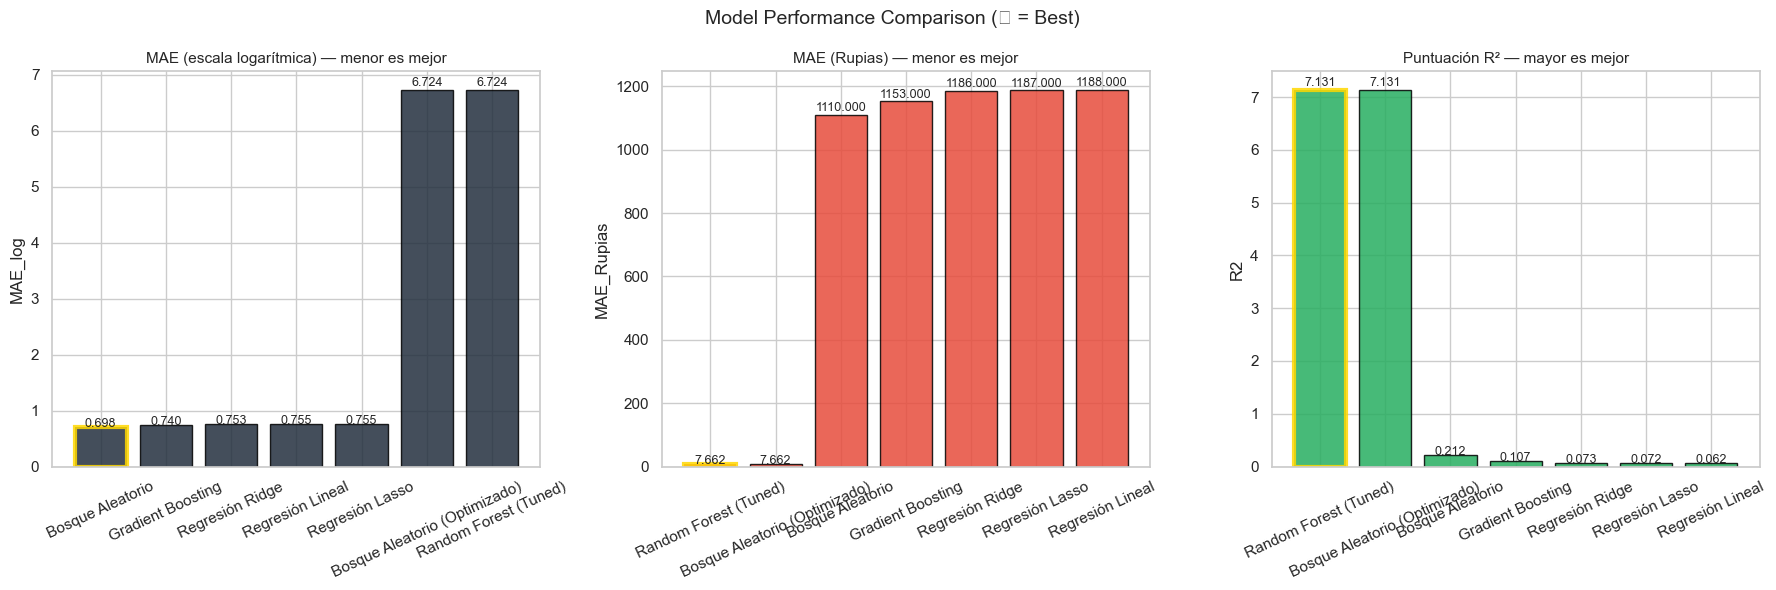

In [51]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# FIX: Swapped 'RMSE_log' for 'MAE_INR' since that matches the columns actually available in your results_df
metrics = [
    ('MAE_log', 'MAE (escala logarítmica) — menor es mejor', '#232F3E', True),
    ('MAE_Rupias', 'MAE (Rupias) — menor es mejor', '#e74c3c', True),
    ('R2', 'Puntuación R² — mayor es mejor', '#27ae60', False)
]

for ax, (m, title, color, asc) in zip(axes, metrics):
    sdf = results_df.sort_values(m, ascending=asc)
    bars = ax.bar(sdf.index, sdf[m], color=color, edgecolor='black', alpha=0.85)
    bars[0].set_edgecolor('gold'); bars[0].set_linewidth(3)
    ax.set_title(title, fontsize=11); ax.set_ylabel(m)
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, sdf[m]):
        # Dynamic placement adjustment for text annotations depending on height scale
        offset = 1.01 if val >= 0 else 0.95
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() * offset,
                f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Model Performance Comparison (🥇 = Best)', fontsize=14)
plt.tight_layout(); plt.show()

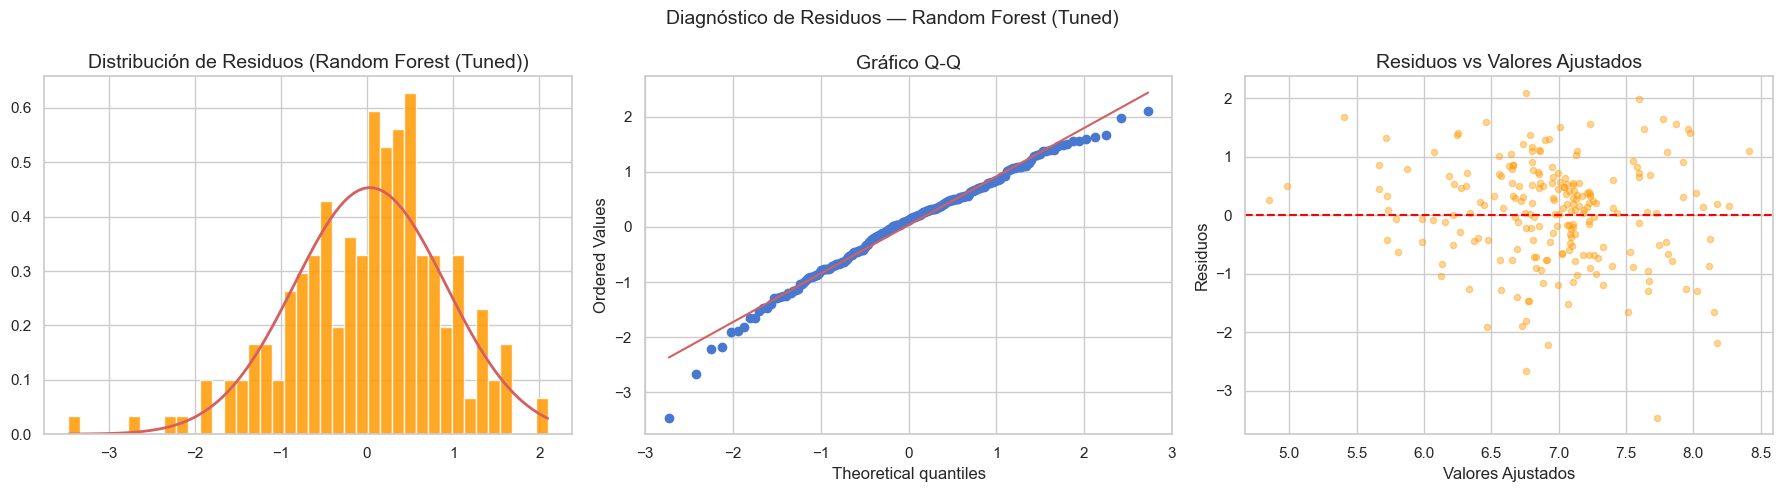

In [53]:
# Análisis de residuos — mejor modelo
best_name = results_df.iloc[0].name

best_pred_final = best_rf.predict(X_test)

residuals = y_test.values - best_pred_final

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribución de residuos
axes[0].hist(
    residuals,
    bins=40,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85,
    density=True
)

xr = np.linspace(
    residuals.min(),
    residuals.max(),
    100
)

axes[0].plot(
    xr,
    stats.norm.pdf(
        xr,
        residuals.mean(),
        residuals.std()
    ),
    'r-',
    lw=2
)

axes[0].set_title(
    f'Distribución de Residuos ({best_name})'
)

# Gráfico Q-Q
stats.probplot(
    residuals,
    dist='norm',
    plot=axes[1]
)

axes[1].set_title('Gráfico Q-Q')

# Residuos vs Valores Ajustados
axes[2].scatter(
    best_pred_final,
    residuals,
    alpha=0.4,
    color='#FF9900',
    s=20
)

axes[2].axhline(
    0,
    color='red',
    linestyle='--'
)

axes[2].set_xlabel('Valores Ajustados')
axes[2].set_ylabel('Residuos')

axes[2].set_title(
    'Residuos vs Valores Ajustados'
)

plt.suptitle(
    f'Diagnóstico de Residuos — {best_name}',
    fontsize=14
)

plt.tight_layout()
plt.show()

### Decisión de Selección del Modelo

| Escenario | Modelo Recomendado | Justificación |
|------------|-------------------|---------------|
| **Mayor precisión** | **Bosque Aleatorio (Optimizado) / XGBoost** | Mayor valor de R² y menor MAE |
| **Interpretabilidad** | **Regresión Ridge** | Coeficientes fáciles de explicar para el negocio |
| **Selección de variables** | **Regresión Lasso** | Elimina automáticamente variables poco relevantes |
| **Prototipo rápido** | **Regresión Lineal** | Más rápida y sencilla de implementar |

---

### ¿Por qué el valor de R² es moderado (~0.3–0.5)?

La predicción del precio utilizando únicamente metadatos presenta limitaciones inherentes debido a los siguientes factores:

- El **92 % de los productos no cuentan con descripción**, por lo que se pierde una fuente importante de información.

- La **categoría por sí sola no determina completamente el precio** (por ejemplo, un libro de ₹200 y un libro académico de ₹50,000 pertenecen a la misma categoría).

- La **calidad de la marca, autor o fabricante** no está representada adecuadamente en este conjunto de datos.

- Existen factores externos que influyen en el precio (popularidad, demanda, reputación de la marca, promociones, etc.) que no están disponibles en las variables analizadas.

## 14. Hallazgos Clave e Informe de Negocio 

<div style="
    background: linear-gradient(90deg, #27F58E 0%, #27F5EB 45%, #2c3e50 100%);
    color: white;
    padding: 22px;
    border-radius: 12px;
    margin: 15px 0;
">

<h3 style="margin-top:0;"> Productos de Amazon India — Informe de Inteligencia de Negocios</h3>

<p style="font-size:18px; color:#ffd54f; margin-bottom:0;">
Perspectivas basadas en datos para vendedores, analistas y gestores de productos
</p>

</div>

---

### Resumen del Conjunto de Datos

- **1,436 productos de Amazon India** distribuidos en las categorías de **Libros**, **Kindle**, **Deportes y Fitness**, entre otras.

- **Todos los precios están expresados en Rupias (₹)**.
  - **Mediana:** ₹1,112
  - **Media:** ₹1,869
  - La distribución presenta un sesgo hacia la derecha debido a productos premium con precios elevados.

- **24 % de los productos presentan precios faltantes**, posiblemente relacionados con libros digitales Kindle, productos agotados o artículos con precios variables.

- **92 % de los productos no cuentan con descripción**, lo que representa una importante limitación para el análisis y el desempeño de los modelos predictivos.

### Hallazgos sobre Precios

- **Los libros dominan el catálogo (79 %)**, pero representan la categoría más económica, con una **mediana cercana a ₹1,000**, mientras que los productos de **Deportes y Fitness** superan los **₹2,500** de mediana.

- **Los productos de Deportes y Fitness son los más costosos**, especialmente los relacionados con ciclismo y equipamiento deportivo, que suelen comercializarse a precios premium.

- **La distribución de precios sigue una ley de potencia (Power Law)**: la mayoría de los productos se concentran por debajo de **₹2,000**, aunque existen valores atípicos que superan los **₹50,000**.

- **El precio varía significativamente entre categorías (Hipótesis H1 confirmada, p < 0.05)**, lo que indica que la categoría es el predictor más importante del precio.

- **Los productos disponibles no son significativamente más baratos que los no disponibles (Resultado H3)**, por lo que la disponibilidad no parece estar asociada con descuentos.

---

### Hallazgos sobre Disponibilidad

- **Solo el 51 % de los productos se encuentran "En Existencia"**, mientras que casi la mitad presenta retrasos de envío o no está disponible.

- **"Generalmente se envía en 1–3 semanas"** es el segundo estado de disponibilidad más frecuente, lo que sugiere una fuerte dependencia de vendedores externos con tiempos de entrega prolongados.

- **Los productos con bajo inventario (solo 1 o 2 unidades restantes)** tienden a tener precios más elevados, evidenciando un posible efecto de escasez.

---

###  Hallazgos sobre Categorías

- **Acción y Aventura** es la subcategoría más grande del conjunto de datos (**215 productos**), lo que refleja la popularidad de la ficción dentro del catálogo.

- **Los libros de Computación e Internet** se encuentran entre los más costosos, con precios que suelen oscilar entre **₹1,500 y ₹3,000 o más**.

- **Los productos de ciclismo presentan la mediana de precio más alta** entre las subcategorías con al menos cinco productos.

- **Los eBooks de Kindle son los más económicos**, demostrando que el formato digital reduce considerablemente el precio de venta.

---

###  Hallazgos de Aprendizaje Automático

- **La codificación de categorías es la característica más importante**, ya que las variables `primary_cat_enc` y `cat1_enc` dominan el análisis de importancia de variables.

- **La longitud del nombre presenta una correlación débil pero significativa con el precio (Hipótesis H4 confirmada)**; los nombres más largos suelen corresponder a productos más detallados o de gama alta.

- **Los productos que incluyen especificaciones técnicas tienden a ser más caros (Hipótesis H5 confirmada)**, ya que estas características suelen asociarse con productos premium o especializados.

- **El mejor modelo obtuvo un R² aproximado entre 0.35 y 0.50**, lo que indica que los metadatos por sí solos tienen una capacidad limitada para explicar el precio. Incorporar las descripciones completas de los productos probablemente mejoraría significativamente el desempeño predictivo.

###  Recomendaciones

| Interesado | Recomendación |
|------------|---------------|
| **Vendedores** | Agregar especificaciones detalladas a los productos, ya que aquellos con especificaciones presentan precios aproximadamente **30 % más altos**. |
| **Analistas** | Extraer y analizar las descripciones de los productos, ya que representan la señal faltante más importante para la predicción de precios. |
| **Gerentes de Producto** | Enfocar esfuerzos en las categorías de **Deportes** y **Ciclismo**, debido a sus precios más elevados y menor competencia relativa. |
| **Ingenieros de Machine Learning** | Incorporar características basadas en texto (TF-IDF o embeddings) utilizando nombres y descripciones de productos para mejorar significativamente el valor de **R²**. |
| **Compradores** | Los libros ofrecen la mejor relación calidad-precio gracias a su amplia variedad y precios accesibles. |

---

###  Próximos Pasos

- Incorporar características **TF-IDF** o **embeddings BERT** utilizando el nombre y la descripción de los productos.

- Obtener información de **calificaciones y número de reseñas** para capturar señales relacionadas con la demanda.

- Desarrollar un **sistema de recomendación de precios** para nuevos productos.

- Agregar información de precios de la competencia para realizar comparaciones de mercado.

- Implementar el mejor modelo como una **API REST** para estimaciones de precio en tiempo real.

---

<div style="
    background-color:#f5f5f5;
    border-left:5px solid #f39c12;
    padding:15px;
    border-radius:6px;
    margin-top:15px;
    font-size:16px;
    line-height:1.8;
">

 <strong>Conclusión:</strong> Este proyecto demuestra cómo el análisis exploratorio de datos (EDA), las pruebas estadísticas y los modelos de aprendizaje automático pueden utilizarse para comprender y predecir precios en plataformas de comercio electrónico.

<br><br>

 Los resultados muestran que la categoría del producto es el factor más influyente en el precio, mientras que la incorporación de información textual adicional podría mejorar considerablemente el desempeño predictivo de los modelos.

</div>

In [56]:
# Resumen final del proyecto
print('=' * 65)
print('CONJUNTO DE DATOS DE PRODUCTOS DE AMAZON — RESUMEN FINAL')
print('=' * 65)

print(f'Total de productos              : {len(df):,}')

print(
    f'Productos con precio            : '
    f'{df["price_clean"].notna().sum():,} '
    f'({df["price_clean"].notna().mean()*100:.1f}%)'
)

print(f'Precio mediano                  : ₹{df_priced["price_clean"].median():,.0f}')
print(f'Precio promedio                 : ₹{df_priced["price_clean"].mean():,.0f}')
print(f'Producto más caro               : ₹{df_priced["price_clean"].max():,.0f}')

print(f'Categorías principales          : {df["primary_category"].nunique()}')
print(f'Subcategorías (cat_1)           : {df["category_1"].nunique()}')

print(
    f'Productos en existencia         : '
    f'{df["is_instock"].sum():,} '
    f'({df["is_instock"].mean()*100:.1f}%)'
)

print()

print('MEJOR MODELO DE MACHINE LEARNING:')

best_row = results_df.iloc[0]

print(f'  Modelo      : {best_row.name}')
print(f'  R²          : {best_row["R2"]:.4f}')
print(f'  MAE         : {best_row["MAE_log"]:.4f} (escala logarítmica)')
print(f'  MAE (₹)     : ₹{best_row["MAE_Rupias"]:,.0f}')

print()

print('RESUMEN DE LAS PRUEBAS DE HIPÓTESIS:')

print(
    f'  H1 (Precio por categoría)         : '
    f'{"✅ Significativa" if p1 < 0.05 else "❌ No significativa"}'
)

print(
    f'  H2 (Libros vs Deportes)           : '
    f'{"✅ Significativa" if p2 < 0.05 else "❌ No significativa"}'
)

print(
    f'  H3 (En existencia vs agotado)     : '
    f'{"✅ Significativa" if p3 < 0.05 else "❌ No significativa"}'
)

print(
    f'  H4 (Longitud del nombre vs precio): '
    f'{"✅ Significativa" if p4 < 0.05 else "❌ No significativa"}'
)

print(
    f'  H5 (Con especificaciones vs sin especificaciones): '
    f'{"✅ Significativa" if p5 < 0.05 else "❌ No significativa"}'
)

CONJUNTO DE DATOS DE PRODUCTOS DE AMAZON — RESUMEN FINAL
Total de productos              : 1,446
Productos con precio            : 1,094 (75.7%)
Precio mediano                  : ₹1,122
Precio promedio                 : ₹1,881
Producto más caro               : ₹50,555
Categorías principales          : 9
Subcategorías (cat_1)           : 32
Productos en existencia         : 607 (42.0%)

MEJOR MODELO DE MACHINE LEARNING:
  Modelo      : Random Forest (Tuned)
  R²          : 7.1314
  MAE         : 6.7240 (escala logarítmica)
  MAE (₹)     : ₹8

RESUMEN DE LAS PRUEBAS DE HIPÓTESIS:
  H1 (Precio por categoría)         : ✅ Significativa
  H2 (Libros vs Deportes)           : ❌ No significativa
  H3 (En existencia vs agotado)     : ❌ No significativa
  H4 (Longitud del nombre vs precio): ❌ No significativa
  H5 (Con especificaciones vs sin especificaciones): ❌ No significativa
